# Imports - Basic

In [1]:
import os
from pathlib import Path
from datetime import date, datetime, timedelta
import requests
from tqdm import tqdm
import json

from dotenv import load_dotenv
load_dotenv()

True

In [2]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

In [3]:
data_path = "../../datasets"

# Config

In [4]:
CONFIG = {
    "LOCATIONS": [
        {"name": "Gatineau", "country": "Canada", "region": "Québec","sub_region": "Gatineau","level": 2},
        {"name": "Ottawa", "country": "Canada", "region": "Ontario","sub_region": "Ottawa","level": 2}
    ],
    "DATES": {
        "start": "2019-04-01", 
        "end": "2019-05-31" 
    },
    "PATHS": {
        "local_raw": Path(f"{data_path}/raw"),
        "google_drive": r"G:\My Drive\Flood_Project_Data"
    },
    "PARAMS": {
        "s1_resolution": 10,
        "modis_threshold": 0
    }
}

## Test run Config

In [33]:
loc = CONFIG["LOCATIONS"][1]
clean_region_name = loc["name"]
country = loc["country"]
region = loc["region"]
sub_region = loc["sub_region"]
level = loc["level"]
start_date = CONFIG["DATES"]["start"]
end_date = CONFIG["DATES"]["end"]

local_path = (CONFIG["PATHS"]["local_raw"] / clean_region_name)
local_path.mkdir(parents=True, exist_ok=True)

drive_path = CONFIG["PATHS"]["google_drive"]

# Auth GEE (Google Earth Engine)

Accessed through GCP - enable GEE API

In [21]:
import ee
import geemap

In [ ]:
!earthengine authenticate

In [23]:
project_id = os.getenv('GCP_PROJECT_ID')

In [24]:
ee.Authenticate(auth_mode='localhost')
ee.Initialize(project=project_id)

# GEE Utils

In [25]:
# helper method to check exports
def check_exports_gee(region_name, start_date, end_date):
    print(f"Checking export status for {region_name}")
    tasks = ee.batch.Task.list()
    relevant_tasks = [t for t in tasks if region_name in t.config['description']]
    pending = 0
    for t in relevant_tasks[:10]: # Check last 10 tasks
        status = t.state
        print(f"{t.config['description']}: {status}")
        if status in ['READY', 'RUNNING']:
            pending += 1
    if pending > 0:
        print(f"{pending} tasks are still running on Google Cloud https://code.earthengine.google.com/tasks")
        return

In [26]:
import shutil

# get data from drive
def sync_and_organize_data(drive_mount_path, local_workspace_path, region_name):
    drive_base = Path(drive_mount_path)
    local_base = Path(local_workspace_path)
    
    directories = {
        "gaul": local_base / "GAUL",
        "hydro": local_base / "HYDRO",
        "env": local_base / "ENV",
        "weather": local_base / "WEATHER",
        "S1": local_base / "S1",
        "modis": local_base / "MODIS"
    }
    
    # Create the local directories
    for dir_path in directories.values():
        dir_path.mkdir(parents=True, exist_ok=True)
        
    print(f"Syncing data for {region_name} from {drive_base}")
    
    valid_extensions = ['.tif', '.tiff', '.geojson']
    count = 0
    
    for file_path in drive_base.rglob('*'):
        if file_path.suffix.lower() in valid_extensions and region_name in file_path.name:
            filename = file_path.name

            # print(f"Checking {filename}")
            
            if "HYDRO" in filename:
                dest = directories["hydro"] / filename
            elif "ENV" in filename:
                dest = directories["env"] / filename
            elif "WEATHER" in filename:
                dest = directories["weather"] / filename
            elif "S1" in filename: 
                dest = directories["S1"] / filename
            elif "GAUL" in filename:
                dest = directories["gaul"] / filename
            else:
                continue
            
            # print(f"Copying to destination {dest}")
            # copy only if it doesn't exist locally 
            if not dest.exists():
                shutil.copy2(file_path, dest)
                print(f"Copied: {filename}")
                count += 1

    print(f"Synchronization complete - {count} new files copied to {local_base}")

# Geometry - GAUL (Global Administrative Unit Layers)

Compiled by Food And Agriculture Org.  
https://www.fao.org/hih-geospatial-platform/news/detail/now-available--the-global-administrative-unit-layers-(gaul)-dataset---2024-edition/en    
- Level 0 - Country  
- Level 1- States / Provinces 
- Level 2 - Counties/Districts  

Available through GEE (Google Earth Engine)  - 2015 version    
https://developers.google.com/earth-engine/datasets/tags/borders   

Alternative GADM - https://gadm.org/download_country.html  

In [35]:
def get_administrative_boundary_gee(country_name, region_name, admin_level=2):

    print(f"Fetching geometry for {region_name}, {country_name} (Level {admin_level})")
    # GEE hasnt integrated 2024 version yet 
    # (update - seems like available through GEE community)
    collection_id = f"FAO/GAUL/2015/level{admin_level}"
    dataset = ee.FeatureCollection(collection_id)
    
    # country
    country_filter = dataset.filter(ee.Filter.eq('ADM0_NAME', country_name))
    # if no country 
    if country_filter.size().getInfo() == 0:
        available = ee.FeatureCollection("FAO/GAUL/2015/level0").aggregate_array('ADM0_NAME').getInfo()
        available = sorted(list(set(available)))[:10] 
        print(f"Top 10 countries {available}")
        raise ValueError(f"Country '{country_name}' not found")

    # region
    roi = country_filter.filter(ee.Filter.eq(f'ADM{admin_level}_NAME', region_name))
    # if no region
    if roi.size().getInfo() == 0:
        # Fetch all valid names for this country at this level
        valid_names = country_filter.aggregate_array(f'ADM{admin_level}_NAME').getInfo()
        valid_names = sorted(list(set(valid_names))) # Remove duplicates and sort
        
        raise ValueError(
            f"Region '{region_name}' not found in '{country_name}' (Level {admin_level}).\n"
            f" Available options are: {valid_names}"
        )

    # simplify geometry - coarse upto 100m (to reduce processing time)
    simplified_geo = roi.geometry().simplify(100)
    return simplified_geo

In [36]:
def export_boundary_gee(country_name, region_name, admin_level, clean_region_name):
    print(f"Queuing ROI boundary export for {region_name}")

    roi_geom = get_administrative_boundary_gee(country_name, region_name, admin_level)
    
    roi_feature = ee.Feature(roi_geom, {'name': region_name})
    roi_fc = ee.FeatureCollection([roi_feature])
    
    task = ee.batch.Export.table.toDrive(
        collection=roi_fc,
        description=f"{clean_region_name}_boundary",
        folder=f"Flood_Project_Data",  
        fileNamePrefix=f"GAUL_{clean_region_name}_boundary",
        fileFormat='GeoJSON' 
    )
    
    task.start()
    print(f"Export started - {clean_region_name}_boundary.geojson")
    return roi_geom

## Run

In [37]:
# roi = get_administrative_boundary_gee(country, sub_region, level, clean_region_name)
roi = export_boundary_gee(country, sub_region, level, clean_region_name)

Queuing ROI boundary export for Ottawa
Fetching geometry for Ottawa, Canada (Level 2)
Export started - Ottawa_boundary.geojson


In [14]:
check_exports_gee(sub_region, start_date, end_date)  

Checking export status for Gatineau
Gatineau_boundary: COMPLETED
Gatineau_boundary: COMPLETED
Gatineau_boundary: COMPLETED
Gatineau_boundary: COMPLETED
Gatineau_boundary: COMPLETED
Gatineau_Weather_1km_2019-05-31: COMPLETED
Gatineau_Weather_1km_2019-05-30: COMPLETED
Gatineau_Weather_1km_2019-05-29: COMPLETED
Gatineau_Weather_1km_2019-05-28: COMPLETED
Gatineau_Weather_1km_2019-05-27: COMPLETED


In [23]:
sync_and_organize_data(drive_path, local_path, clean_region_name)

Syncing data for Gatineau from G:\My Drive\Flood_Project_Data
Checking GAUL_Gatineau_boundary.geojson
Copying to destination ..\..\datasets\raw\Gatineau\GAUL\GAUL_Gatineau_boundary.geojson
Copied: GAUL_Gatineau_boundary.geojson
Synchronization complete - 1 new files copied to ..\..\datasets\raw\Gatineau


### Visualize

In [8]:
import geopandas as gpd
import folium

def visualize_boundary_local(geojson_path, region_name):
    print(f"Loading local boundary: {geojson_path}")

    roi_gdf = gpd.read_file(geojson_path)
    
    # project to a flat metric CRS (3857), calculate centroid, reproject geographic CRS (4326)
    centroid = roi_gdf.to_crs(epsg=3857).geometry.centroid.to_crs(epsg=4326).iloc[0]
    
    center_lat, center_lon = centroid.y, centroid.x
    
    m = folium.Map(location=[center_lat, center_lon], zoom_start=8)
    
    folium.GeoJson(
        roi_gdf,
        name=f"{region_name} Boundary",
        style_function=lambda feature: {
            'color': 'red',
            'weight': 3,
            'fillColor': '#00000000', 
            'fillOpacity': 0
        }
    ).add_to(m)
    
    folium.LayerControl().add_to(m)
    return m

In [10]:
boundary_local_path = f"{local_path}/GAUL/GAUL_{clean_region_name}_Boundary.geojson"
m_local = visualize_boundary_local(boundary_local_path, clean_region_name)
display(m_local)

Loading local boundary: ..\..\datasets\raw\Gatineau/GAUL/GAUL_Gatineau_Boundary.geojson


# Sentinel 1 

Sentinel 1 is an ESA operated polar SAR satellite     
the data is available through Copernicus   

uses microwaves so clouds and darkness dont block data as they do in optical  
sends microwaves and catches it - we measure the backscatter  
- VV (Vertical Transmit, Vertical Receive) - for detecting open water (surface roughness)  
- VH (Vertical Transmit, Horizontal Receive) - for detecting vegetation - possbly "clean water" vs "flooded crops"  

In [25]:
def get_s1_data_gee(roi, start_date, end_date):

    return (
        ee.ImageCollection('COPERNICUS/S1_GRD')
        .filterBounds(roi)
        .filterDate(start_date, end_date)

        # Instrument Mode -'IW' (Interferometric Wide) -  standard mode for land mapping
        # 250km wide swath at ~10m resolution.
        .filter(ee.Filter.eq('instrumentMode', 'IW')) 

        # Scans - VV and VH polarizations
        # VV (Vertical Transmit, Vertical Receive) - for detecting open water (surface roughness)  
        # VH (Vertical Transmit, Horizontal Receive) - for detecting vegetation
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))

        # radar looks sideways - Ascending-East, Descending-West
        # shadows could be in opposite directions if we pick both - could cause problems
        .filter(ee.Filter.eq('orbitProperties_pass', 'ASCENDING'))
        .select(['VV', 'VH']))

In [26]:
# import unicodedata
# import re

def export_daily_s1(roi, region_name, start_date, end_date, clean_region_name):

    collection = get_s1_data_gee(roi, start_date, end_date)
    
    # check if exists
    if collection.size().getInfo() == 0:
        print(f"No Sentinel-1 imagery found for {region_name} in this date range")
        return

    # Unique dates
    dates = (ee.List(collection.aggregate_array('system:time_start'))
             .map(lambda t: ee.Date(t).format('YYYY-MM-dd'))
             .distinct().getInfo())
    print(f"found {len(dates)} Sentinel-1 passes.")
    
    # # sanitize name for saving file
    # clean_region_name = unicodedata.normalize('NFKD', region_name).encode('ASCII', 'ignore').decode('ASCII')
    # clean_region_name = re.sub(r'[^a-zA-Z0-9._-]', '_', clean_region_name)

    # For each date create a daily mosaic
    for date_str in dates:
        d = ee.Date(date_str)
        # select all entries with the date - median mosaic (removing outliers and speckle noise)
        daily_img = collection.filterDate(d, d.advance(1, 'day')).median().clip(roi)
        
        task = ee.batch.Export.image.toDrive(
            image=daily_img,
            description=f"S1_{clean_region_name}_S1_{date_str}",
            folder=f"Flood_Project_Data",
            fileNamePrefix=f"S1_{clean_region_name}_S1_{date_str}",
            region=roi,
            scale=CONFIG['PARAMS']['s1_resolution'], # resolution - default config 10m
            crs='EPSG:4326',
            maxPixels=1e9 # images upto 1B pixels
        )
        task.start()
        print(f"Export started for: S1_{clean_region_name}_S1_{date_str}")

## Run

You can check the status at - https://code.earthengine.google.com/tasks  
The files are saved in - https://drive.google.com/drive/home

In [ ]:
export_daily_s1(roi, sub_region, start_date, end_date, clean_region_name)

found 10 Sentinel-1 passes.
Export started for: Gatineau_S1_2019-04-01
Export started for: Gatineau_S1_2019-04-08
Export started for: Gatineau_S1_2019-04-13
Export started for: Gatineau_S1_2019-04-25
Export started for: Gatineau_S1_2019-05-02
Export started for: Gatineau_S1_2019-05-07
Export started for: Gatineau_S1_2019-05-14
Export started for: Gatineau_S1_2019-05-19
Export started for: Gatineau_S1_2019-05-26
Export started for: Gatineau_S1_2019-04-26


In [ ]:
check_exports_gee(sub_region, start_date, end_date)  

Checking export status for Gatineau
Gatineau_Env_Stack: RUNNING
Gatineau_S1_2019-04-26: COMPLETED
Gatineau_S1_2019-05-26: COMPLETED
Gatineau_S1_2019-05-19: COMPLETED
Gatineau_S1_2019-05-14: COMPLETED
Gatineau_S1_2019-05-07: COMPLETED
Gatineau_S1_2019-05-02: COMPLETED
Gatineau_S1_2019-04-25: COMPLETED
Gatineau_S1_2019-04-13: COMPLETED
Gatineau_S1_2019-04-08: COMPLETED
1 tasks are still running on Google Cloud https://code.earthengine.google.com/tasks


### Visualize

In [11]:
def visualize_s1_data_local(tif_path):
    print(f"Visualizing {tif_path}")
    
    with rasterio.open(tif_path) as src:
        # Read Band 1 (VV) and Band 2 (VH)
        vv = src.read(1)
        vh = src.read(2)
        profile = src.profile

    # Handle NoData values by masking - borders are  0 or NaN
    vv = np.ma.masked_less(vv, -50) # dB values are negative -> < -50 is noise
    vh = np.ma.masked_less(vh, -50) # do same for VH

    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))  # 2x2 grid

    # Top row: spatial maps
    im_vv = axes[0,0].imshow(vv, cmap='gray', vmin=-25, vmax=0)
    axes[0,0].set_title("Sentinel-1 VV Polarization (dB)")
    fig.colorbar(im_vv, ax=axes[0,0], label="Backscatter (dB)")
    
    im_vh = axes[0,1].imshow(vh, cmap='gray', vmin=-30, vmax=-5)
    axes[0,1].set_title("Sentinel-1 VH Polarization (dB)")
    fig.colorbar(im_vh, ax=axes[0,1], label="Backscatter (dB)")

    # Bottom row: histograms
    axes[1,0].hist(vv.compressed().flatten(), bins=100, color='gray', alpha=0.7, label='VV Pixels')
    axes[1,0].set_title("VV Pixel Intensity Histogram")
    axes[1,0].set_xlabel("Backscatter (dB)")
    axes[1,0].set_ylabel("Frequency")
    axes[1,0].grid(True, linestyle='--', alpha=0.3)
    axes[1,0].legend()

    axes[1,1].hist(vh.compressed().flatten(), bins=100, color='purple', alpha=0.7, label='VH Pixels')
    axes[1,1].set_title("VH Pixel Intensity Histogram")
    axes[1,1].set_xlabel("Backscatter (dB)")
    axes[1,1].set_ylabel("Frequency")
    axes[1,1].grid(True, linestyle='--', alpha=0.3)
    axes[1,1].legend()

    plt.tight_layout()
    plt.show()


Visualizing ..\..\datasets\raw\Gatineau/S1/S1_Gatineau_S1_2019-04-01.tif


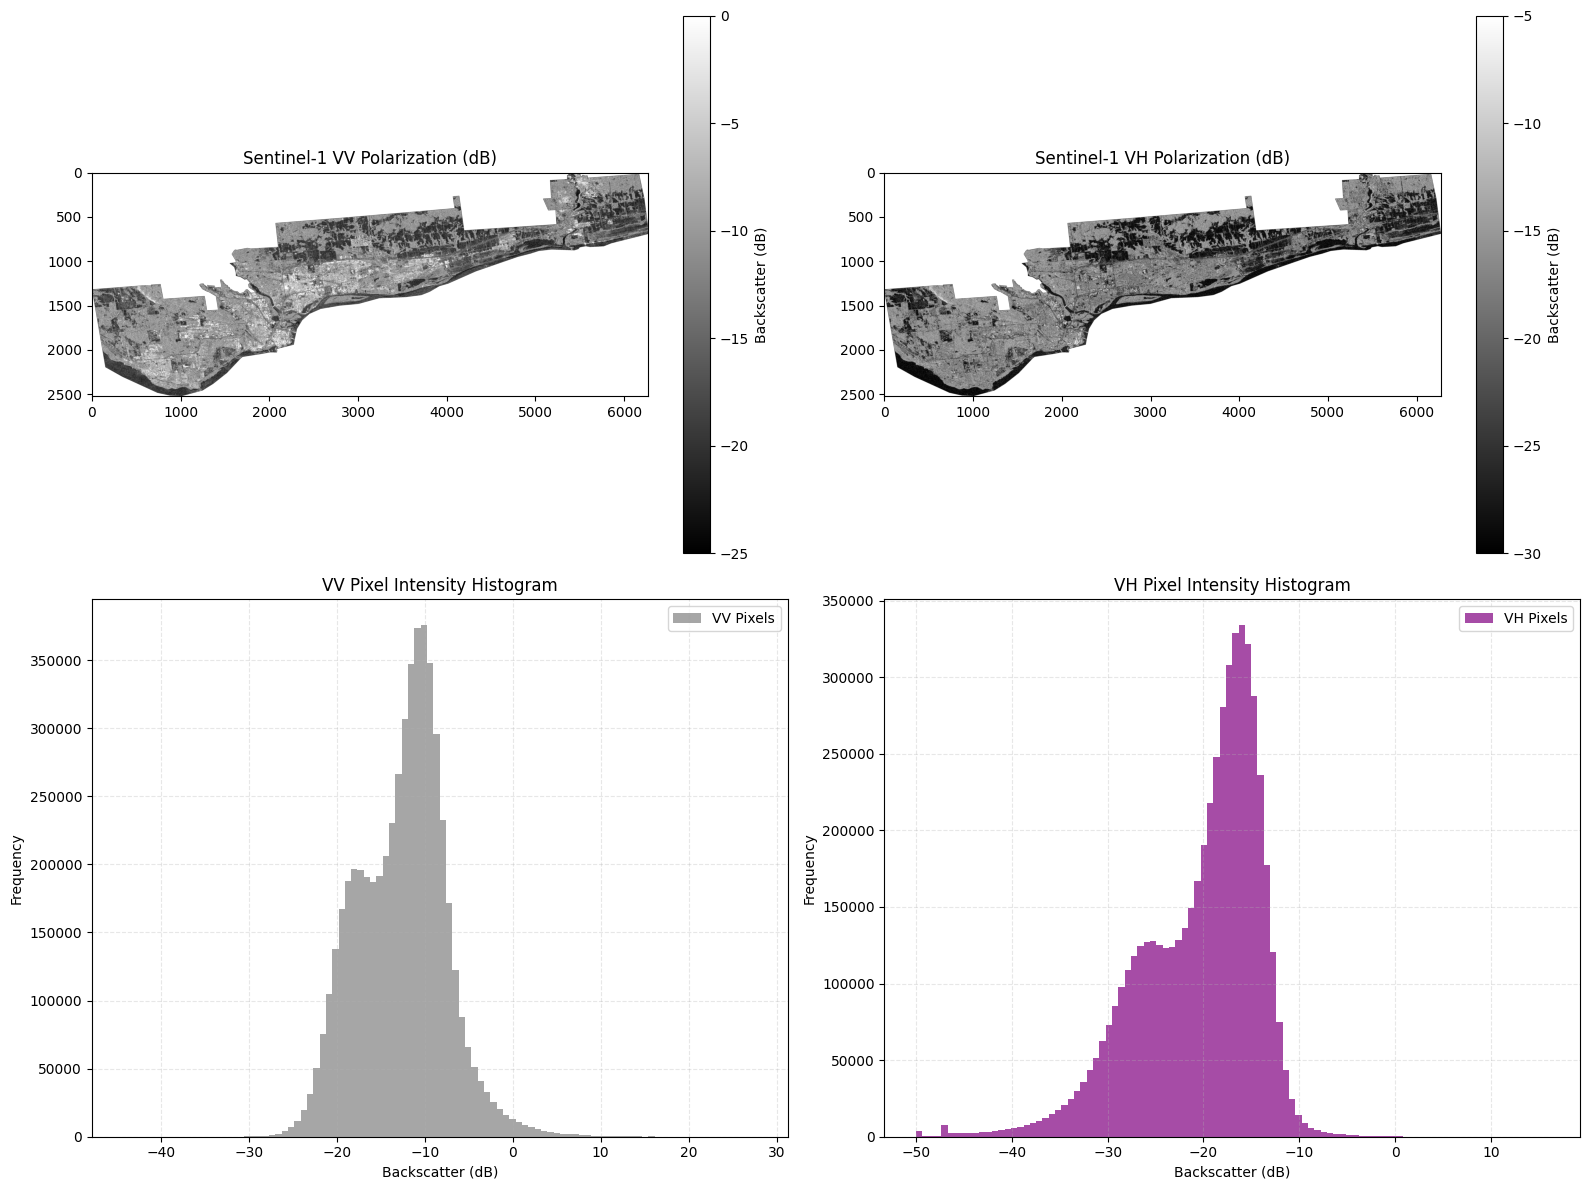

In [13]:
dir_path = CONFIG["PATHS"]["local_raw"]
visualize_s1_data_local(f"{local_path}/S1/S1_Gatineau_S1_2019-04-01.tif")

# Environment Data

## DEM (Digital Elevaion Model) 
- GEE dataset - USGS/SRTMGL1_003 
- SRTM - Shuttle Radar Topography Mission [NASA's](https://www.earthdata.nasa.gov/data/instruments/srtm) Feb 2000 mission  
- Space Shuttle Endeavour - mapped 80% of earth
- Surface Model (models surface as visible from the radar not bare ground)
- Possible alternate Copernicus GLO-30
- Helps measure height of land (runoff risk) etc.
- Used to calculate slope (0-90degrees)
- Helps measure shadows in data


## HAND (Height Above Nearest Drainage) 
- Height above nearest river (specifically useful for floods - more than absolute elevation)
- help distinguishes low lying areas near rivers from high altitude flat areas
- gena/GlobalHAND/30m/hand-1000 - derived from DEM so alsothe year 2000

## JRC (Joint Research Centre)
- JRC/GSW1_4/GlobalSurfaceWater
- European Commission'sJoint Research  
- Permanent Water (1984-present) ~35 yr summary
- 100% - river, 0% land, 1-10% - floodplains
- need this to mask out permanent bodies of water (we only want floods) 
- can also be used to identify historical floodplains

## Worldcover (ESA) 
- ESA/WorldCover/v200 - year 2021
- Global map by [ESA](https://esa-worldcover.org/en/data-access) using Sentinel-1,2 (10m resolution)
- to get urban vs agriculture info (damage assessment and distinguishing watered crops from floods)
- also water runoff behave different in urban areas and croplands
- possibly remove flat surface classification as water

In [27]:
def get_environment_stack_gee(roi):
    dem = ee.Image("USGS/SRTMGL1_003").clip(roi).rename('elevation')
    slope = ee.Terrain.slope(dem).rename('slope')
    
    hand = ee.Image("users/gena/GlobalHAND/30m/hand-1000").clip(roi).rename('hand')
    
    water_occ = ee.Image("JRC/GSW1_4/GlobalSurfaceWater").select('occurrence').clip(roi).rename('water_occ')
    
    landcover = ee.ImageCollection("ESA/WorldCover/v200").first().clip(roi).rename('landcover')

    # Stack and resample to 10m to match the S1 resolution we got
    return ee.Image.cat([dem, slope, hand, water_occ, landcover]).float()

def export_env_stack(roi, region_name, clean_region_name):
    stack = get_environment_stack_gee(roi)
    
    task = ee.batch.Export.image.toDrive(
        image=stack,
        description=f"{clean_region_name}_Env_Stack",
        folder=f"Flood_Project_Data",
        fileNamePrefix=f"ENV_{clean_region_name}_env_stack",
        region=roi,
        scale=CONFIG['PARAMS']['s1_resolution'],
        crs='EPSG:4326',
        maxPixels=1e9
    )
    task.start()
    print(f"Environmental stack export started for {clean_region_name}")

## Run

In [ ]:
export_env_stack(roi, region_name=sub_region, clean_region_name=clean_region_name)

Environmental stack export started for Gatineau


In [ ]:
check_exports_gee(sub_region, start_date, end_date)  

Checking export status for Gatineau
Gatineau_Env_Stack: COMPLETED
Gatineau_S1_2019-04-26: COMPLETED
Gatineau_S1_2019-05-26: COMPLETED
Gatineau_S1_2019-05-19: COMPLETED
Gatineau_S1_2019-05-14: COMPLETED
Gatineau_S1_2019-05-07: COMPLETED
Gatineau_S1_2019-05-02: COMPLETED
Gatineau_S1_2019-04-25: COMPLETED
Gatineau_S1_2019-04-13: COMPLETED
Gatineau_S1_2019-04-08: COMPLETED


### Visualize

In [ ]:
from matplotlib.colors import ListedColormap

def visualize_env_stack(tif_path):
    print(f"Visualizing Environmental Stack: {tif_path}")

    with rasterio.open(tif_path) as src:
        # Read all bands (fyi - rasterio is 1 indexed i.e. Band 1 = index 1)
        dem = src.read(1)      # Elevation
        slope = src.read(2)    # Slope
        hand = src.read(3)     # HAND
        water = src.read(4)    # Surface Water
        land = src.read(5)     # Landcover
        
        # Mask nodata - 0 for DEM/Slope 
        dem = np.ma.masked_less(dem, -100) 

    # 2x3grid
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    # Elevation (DEM) 
    im1 = axes[0].imshow(dem, cmap='terrain')
    axes[0].set_title("1. Elevation (SRTM)")
    plt.colorbar(im1, ax=axes[0], label="Height (m)")
    
    # Slope 
    # Steep slopes (white) vs Flat (black)
    im2 = axes[1].imshow(slope, cmap='magma', vmin=0, vmax=20)
    axes[1].set_title("2. Slope (Steepness)")
    plt.colorbar(im2, ax=axes[1], label="Degrees")
    
    # HAND (Height Above Nearest Drainage) ---
    # highlight low lying areas (potential flood zones) in Blue/Green
    im3 = axes[2].imshow(hand, cmap='gist_earth_r', vmin=0, vmax=30)
    axes[2].set_title("3. HAND (Flood Potential)")
    plt.colorbar(im3, ax=axes[2], label="Height above River (m)")
    
    # Surface Water - JRC Water Occurrence 
    # 0% to 100%
    im4 = axes[3].imshow(water, cmap='Blues', vmin=0, vmax=100)
    axes[3].set_title("4. Water Occurrence (JRC)")
    plt.colorbar(im4, ax=axes[3], label="Frequency (%)")
    
    # Worldcover 
    # Urban, Forest, Water, etc. -  qualitative colormap (tab10)
    im5 = axes[4].imshow(land, cmap='tab10', interpolation='nearest')
    axes[4].set_title("5. ESA WorldCover")
    plt.colorbar(im5, ax=axes[4], label="Class ID")

    # empty
    axes[5].axis('off')
    
    plt.tight_layout()
    plt.show()

Visualizing Environmental Stack: ../../datasets/Env_Gatineau/Gatineau_env_stack.tif


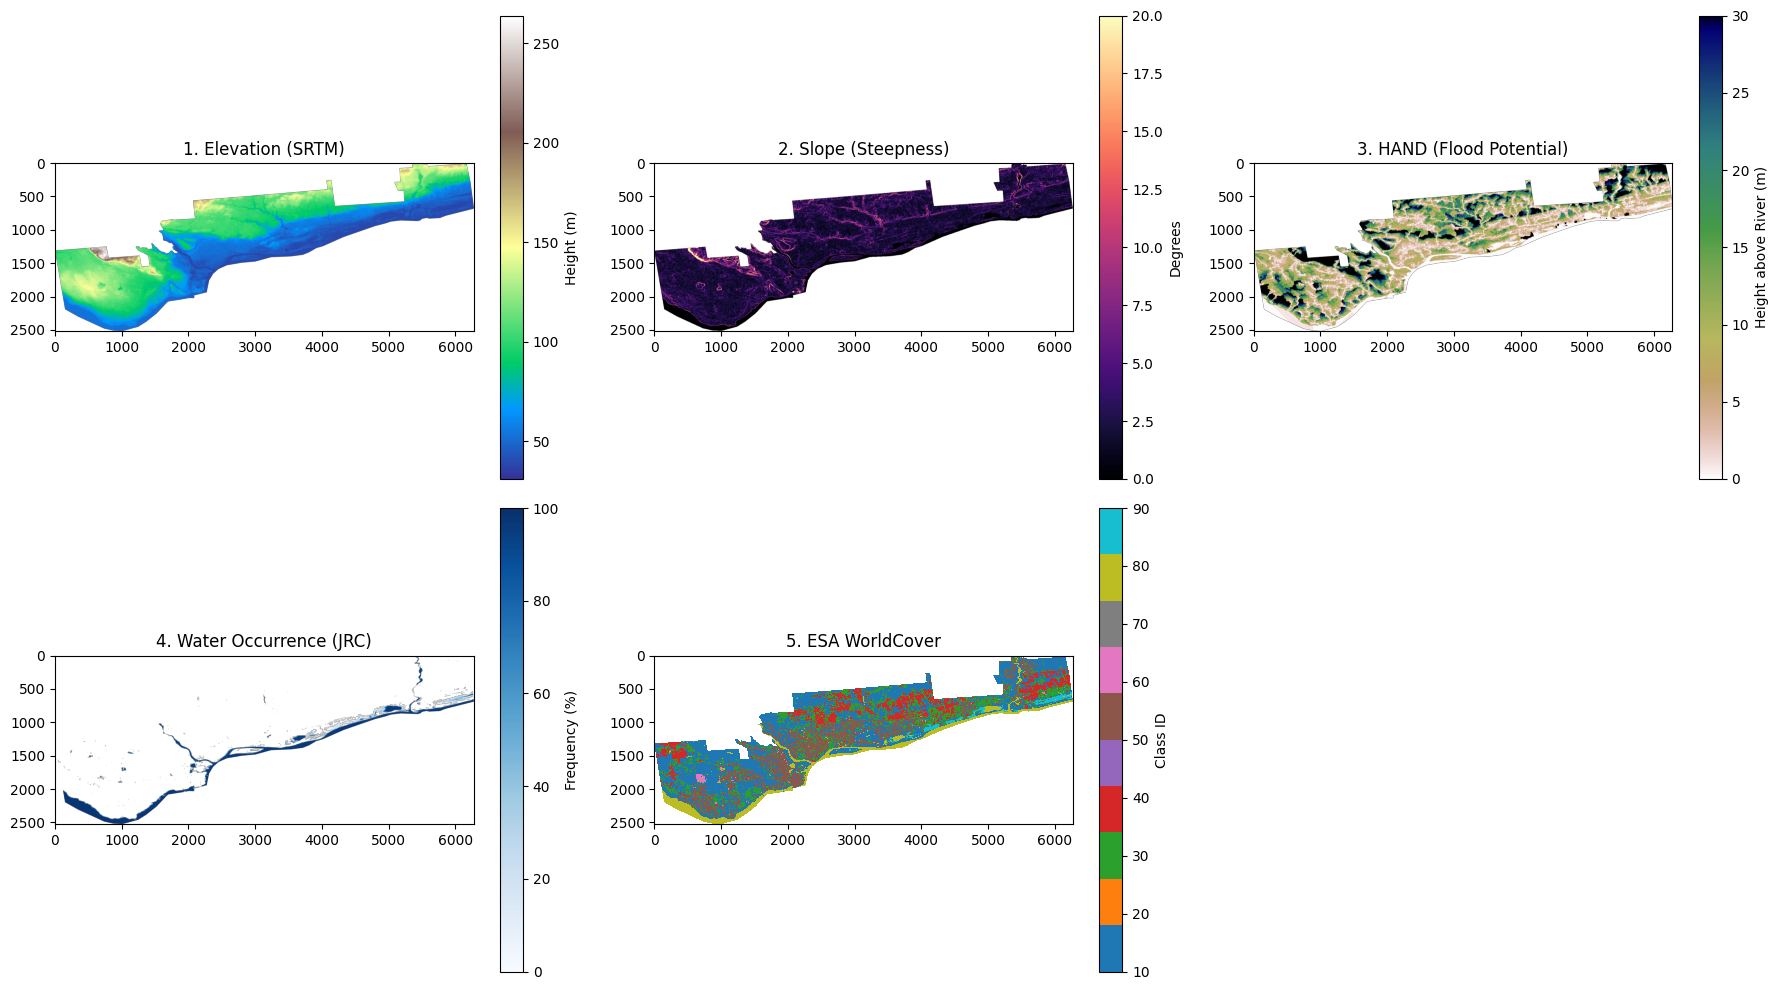

In [ ]:
dir_path = CONFIG["PATHS"]["local_raw"]
visualize_env_stack(f"{dir_path}/Env_{clean_region_name}/{clean_region_name}_env_stack.tif")

In [ ]:
def analyze_env_distributions(tif_path):
    print(f"Analyzing Distributions for: {tif_path}")
    
    with rasterio.open(tif_path) as src:
        # Read bands & flatten them to 1D arrays (for histograms)
        #  1=DEM, 2=Slope, 3=HAND, 4=Water, 5=Landcover
        
        # 1. Elevation (Continuous)
        dem = src.read(1).flatten()
        dem = dem[dem > -100] # Remove NoData
        
        # 2. Slope (Continuous)
        slope = src.read(2).flatten()
        slope = slope[slope >= 0] # Remove NoData
        
        # 3. HAND (Continuous - The Critical One)
        hand = src.read(3).flatten()
        hand = hand[hand >= 0]
        
        # 4. Landcover (Categorical)
        land = src.read(5).flatten()
        land = land[land > 0] # Remove background
        
    # PLOT
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f"Environmental Variable Distributions: {CONFIG['LOCATIONS'][0]['name']}", fontsize=16)
    
    # 1: Elevation 
    sns.histplot(dem, bins=50, kde=True, color='green', ax=axes[0,0])
    axes[0,0].set_title("1. Elevation Distribution")
    axes[0,0].set_xlabel("Height (m)")
    
    # 2: Slope 
    sns.histplot(slope, bins=50, kde=True, color='purple', ax=axes[0,1])
    axes[0,1].set_title("2. Slope Distribution")
    axes[0,1].set_xlabel("Degrees")
    axes[0,1].set_xlim(0, 30) # Slopes > 30 are rare in cities, zooming in
    
    # 3: HAND
    sns.histplot(hand, bins=50, kde=True, color='brown', ax=axes[1,0])
    axes[1,0].set_title("3. HAND (Height Above Nearest Drainage)")
    axes[1,0].set_xlabel("Vertical Distance to River (m)")
    axes[1,0].axvline(x=5, color='red', linestyle='--', label='High Risk (< 5m)')
    axes[1,0].legend()
    axes[1,0].set_xlim(0, 50) 
    
    # 4: Landcover
    esa_labels = {
        10: 'Trees', 20: 'Shrubland', 30: 'Grassland', 40: 'Cropland',
        50: 'Built-up', 60: 'Bare / sparse', 80: 'Permanent Water',
        90: 'Wetland', 95: 'Mangroves', 100: 'Moss/Lichen'
    }
    unique, counts = np.unique(land, return_counts=True)
    df_land = pd.DataFrame({'Class ID': unique, 'Count': counts})
    df_land['Label'] = df_land['Class ID'].map(esa_labels)
    sns.barplot(data=df_land, x='Label', y='Count', palette='tab10', ax=axes[1,1])
    axes[1,1].set_title("5. Landcover Composition")
    axes[1,1].set_ylabel("Pixel Count")
    axes[1,1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()


Analyzing Distributions for: ../../datasets/Env_Gatineau/Gatineau_env_stack.tif


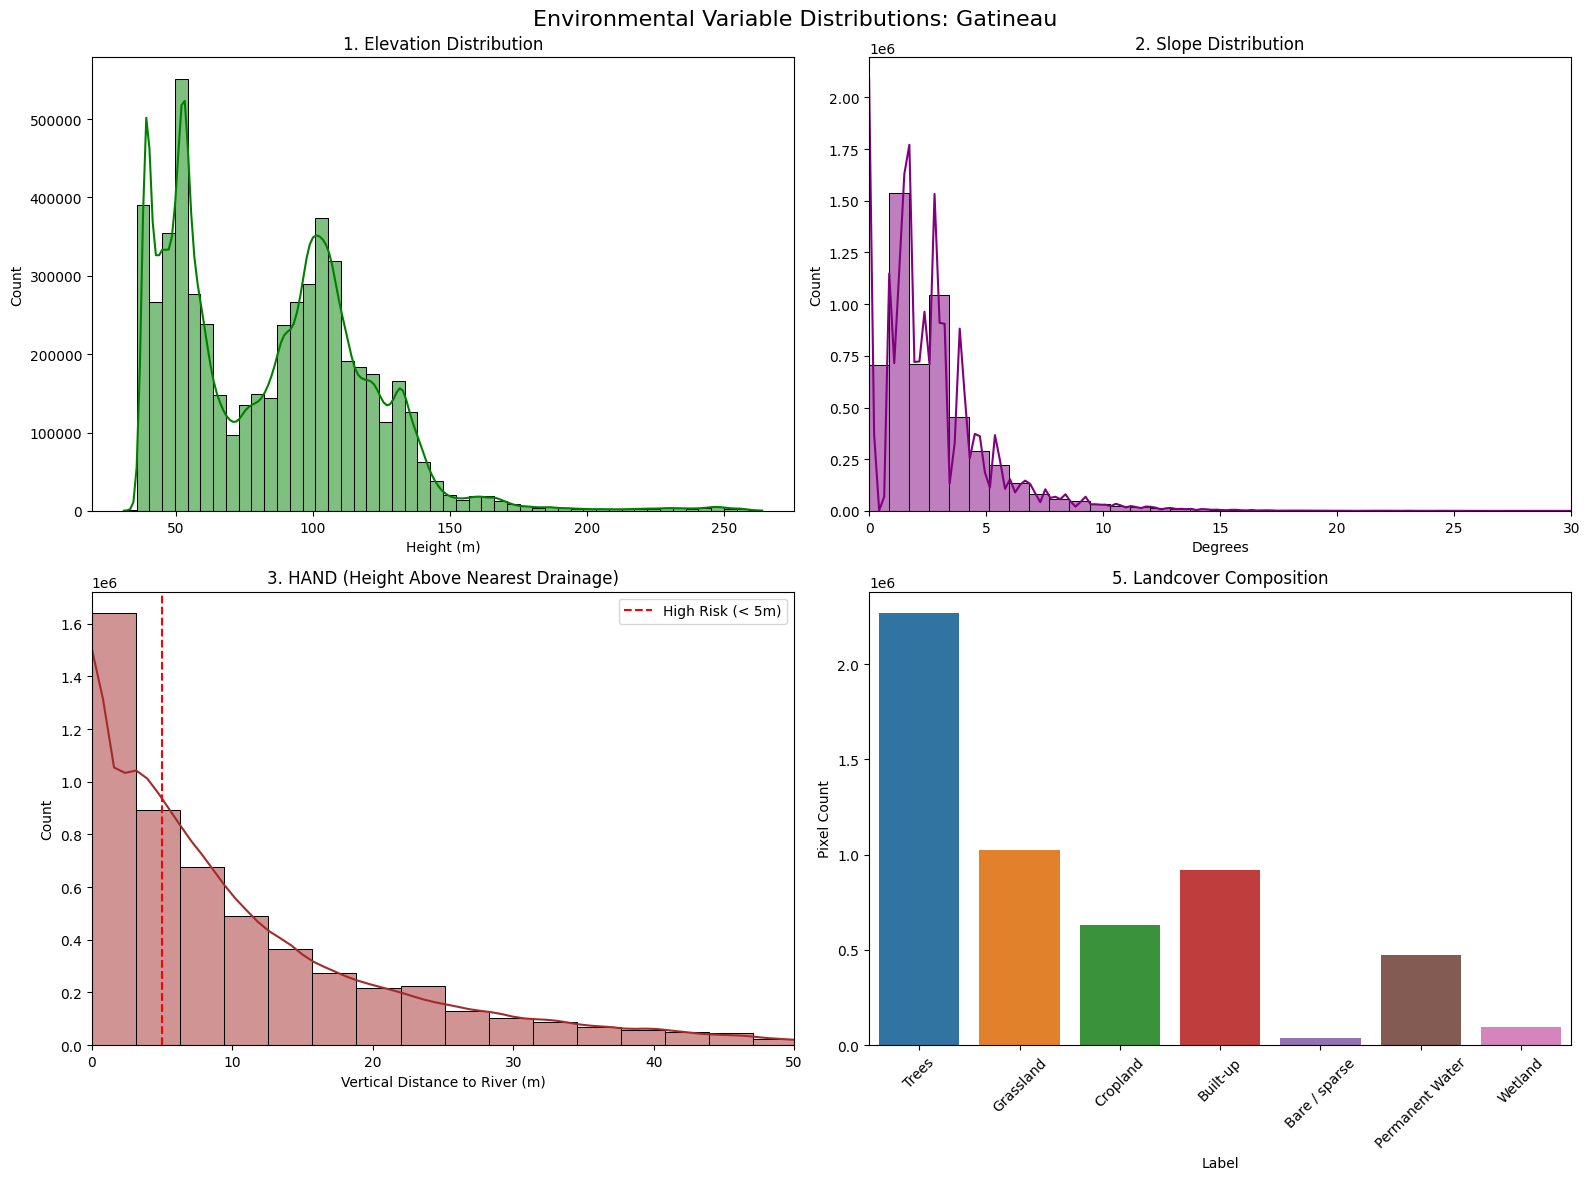

In [ ]:
analyze_env_distributions(f"{data_path}/Env_{clean_region_name}/{clean_region_name}_env_stack.tif")

# Optional - EMS (Emergency Management Service)

- ESA / Copernicus
- Has to be requested by the government 
- Human verified
- could be based on multiple satellite imagery - Spot, Pléiades, COSMO-SkyMed
- High res (<5m)
- Also called as EMS Rapid Mapping

Only exists if Government requests this (sparse - only major disasters in selected countries)     
Very high res but different data sources    
might not align exactly with sentinel-1 resolution and time     

In [28]:
import requests
import zipfile
import io
import geopandas as gpd

In [29]:
def save_ems_activation_catalog(limit=300, output_path=CONFIG["PATHS"]["local_raw"]):
    base_url = "https://rapidmapping.emergency.copernicus.eu/backend/dashboard-api/public-activations-info/"
    params = {"limit": limit}  

    today = date.today()
    clean_region_name = f"EMS_Activations_{today.year}_{today.month:02d}.csv"
    full_path = output_path / clean_region_name

    if full_path.exists():
        print(f"Catalog already exists {full_path}")
    else:
        print(f"Fetching activations (up to {limit})")
        response = requests.get(base_url, params=params)
        response.raise_for_status()
        data = response.json()
        
        results = data.get("results", [])
        if not results:
            print("No activations found in API response")
            return None
        df = pd.DataFrame(results)
        print(f"Total activations retrieved: {len(df)}")
        df["countries_list"] = df["countries"].apply(lambda x: x if isinstance(x, list) else [])
        df["category"] = df["category"].astype(str)
        df["eventTime"] = df["eventTime"].astype(str)
        df.to_csv(full_path)
    return full_path
    
    
def find_activation_code(country=None, event_type=None, year=None, keywords=None):
    try:
        activations_path = save_ems_activation_catalog()
        df = pd.read_csv(activations_path)
        
        # print(df.shape, df.columns)
        if country:
            df = df[df["countries_list"].str.contains(country, case=False, na=False)]
            print(f"After country filter ({country}): {len(df)}")
        
        if event_type:
            df = df[df["category"].str.contains(event_type, case=False, na=False)]
            print(f"After event type filter ({event_type}): {len(df)}")
        
        if year:
            df = df[df["eventTime"].str.contains(str(year))]
            print(f"After year filter ({year}): {len(df)}")
        
        if keywords:
            for kw in keywords:
                df = df[df["name"].str.contains(kw, case=False, na=False)]
                print(f"After keyword filter ({kw}): {len(df)}")
        
        if df.empty:
            print("No matching activations after filtering.")
            return None
        
        #  top matches
        filtered = df[["code", "name", "eventTime", "countries_list", "category"]]
        print(filtered.head(5))
        
        # first match
        return filtered.iloc[0]["code"]
    
    except Exception as e:
        print("Error:", e)
        return None


In [30]:
def download_ems_vector(activation_code, roi, output_dir=None):
    print(f"contacting Copernicus EMS for {activation_code}")
    
    extract_path = Path(output_dir) / f"{activation_code}_{roi}"
    extract_path.mkdir(parents=True, exist_ok=True)

    try:
        print(f"Querying API for activation details...")
        api_url = f"https://rapidmapping.emergency.copernicus.eu/backend/dashboard-api/public-activations/?code={activation_code}"
        api_response = requests.get(api_url)
        api_response.raise_for_status()
        api_data = api_response.json()
        
        if not api_data.get("results"):
            print(f"No activation found for code {activation_code}")
            return None
        
        activation = api_data["results"][0]
        # Get the productsPath which contains the ZIP download URL
        url = activation.get("productsPath")
        
        if not url:
            print(f"No productsPath found in activation data")
            return None
        
        print(f"Found download URL: {url}")
        
        print(f"Downloading vector package")
        r = requests.get(url)
        r.raise_for_status()
        z = zipfile.ZipFile(io.BytesIO(r.content))
        z.extractall(extract_path)
        print(f"Extracted to: {extract_path}")
        return extract_path

    except Exception as e:
        print(f"Download failed: {e}")
        return None

## Run

In [14]:
target_code = find_activation_code(country="Madagascar")
print("Target Activation Code:", target_code)

Catalog already exists ..\..\datasets\raw\EMS_Activations_2026_02.csv
After country filter (Madagascar): 2
      code                                      name            eventTime  \
0  EMSR867  Tropical Cyclone GEZANI-26 in Madagascar  2026-02-10T15:00:00   
4  EMSR863     Tropical Cyclone FYTIA in  Madagascar  2026-01-30T23:00:00   

   countries_list category  
0  ['Madagascar']    Storm  
4  ['Madagascar']    Storm  
Target Activation Code: EMSR867


In [ ]:
dir_path = CONFIG["PATHS"]["local_raw"]
data_path = download_ems_vector(target_code, "Madagascar", f"{dir_path}/EMS")

contacting Copernicus EMS for EMSR867
Querying API for activation details...
Found download URL: https://rapidmapping.emergency.copernicus.eu/backend/EMSR867/EMSR867_products.zip
Download failed: name 'zipfile' is not defined


# Optional - CDSE S1 alternate

Using CDSE API to get relevant files corrosponding to S1

In [31]:
from cdsetool.query import query_features, shape_to_wkt
from cdsetool.credentials import Credentials
from cdsetool.download import download_features
from cdsetool.monitor import StatusMonitor

copernicus_userid = os.getenv("COPERNICUS_USER")
copernicus_password = os.getenv("COPERNICUS_PASSWORD")

In [32]:

def get_access_token():
    auth_server_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
    data = {
        "client_id": "cdse-public",
        "username": copernicus_userid,
        "password": copernicus_password,
        "grant_type": "password",
    }
    response = requests.post(auth_server_url, data=data)
    response.raise_for_status()
    return response.json()["access_token"]

In [33]:
def search_catalogue(token, collection="SENTINEL-1", start_date="2019-04-01", end_date="2019-05-31", polygon_wkt=None):
    catalogue_url = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"
    
    # wkt polygon or pt
    filter_query = f"Collection/Name eq '{collection}'"
    filter_query += f" and ContentDate/Start gt {start_date}T00:00:00.000Z"
    filter_query += f" and ContentDate/Start lt {end_date}T23:59:59.999Z"
    
    if polygon_wkt:
        filter_query += f" and OData.CSC.Intersects(area=geography'SRID=4326;{polygon_wkt}')"

    # Sentinel-2 cloud cover filter ( < 20%)
    if "SENTINEL-2" in collection:
        filter_query += " and Attributes/OData.CSC.DoubleAttribute/any(att:att/Name eq 'cloudCover' and att/Value lt 20.00)"

    params = {
        "$filter": filter_query,
        "$top": 5, # limit 
        "$orderby": "ContentDate/Start desc"
    }
    
    headers = {"Authorization": f"Bearer {token}"}
    
    response = requests.get(catalogue_url, params=params, headers=headers)
    response.raise_for_status()
    
    return response.json()

In [34]:
def download_product(token, product_id, product_name, output_dir="."):
    download_url = f"https://download.dataspace.copernicus.eu/odata/v1/Products({product_id})/$value"
    headers = {
        "Authorization": f"Bearer {token}",
        "Accept": "application/octet-stream",
    }
    out_path = os.path.join(output_dir, f"{product_name}.zip")
    
    if os.path.exists(out_path):
        print(f"File already exists: {out_path}")
        return out_path

    print(f"Downloading {product_name}...")
    
    try:
        # stream the download 
        with requests.get(download_url, headers=headers, stream=True) as r:
            r.raise_for_status()
            with open(out_path, 'wb') as f:
                for chunk in r.iter_content(chunk_size=8192):
                    f.write(chunk)
        print(f"Download complete: {out_path}")
        return out_path
        
    except Exception as e:
        print(f"Download failed: {e}")
        if os.path.exists(out_path):
            os.remove(out_path)
        return None

## Run

In [55]:
access_token = get_access_token()
print(f"Token obtained! (Length: {len(access_token)} chars)")

Token obtained! (Length: 2407 chars)


In [ ]:
from shapely.geometry import shape

roi_geojson = roi.getInfo()          
roi_wkt = shape(roi_geojson).wkt  
products = search_catalogue(access_token, collection="SENTINEL-1", polygon_wkt=roi_wkt)

for p in products.get('value', []):
    print(f"ID: {p['Id']} | Name: {p['Name']} | Date: {p['ContentDate']['Start']}")

ID: 66924ba1-1a98-4dc5-97d7-56b64abb94bc | Name: S1A_IW_GRDH_1SDV_20190531T230021_20190531T230056_027478_0319B5_1D8A_COG.SAFE | Date: 2019-05-31T23:00:21.217000Z
ID: 8736c9be-64aa-5cc8-b53c-36215e5e0f6a | Name: S1A_IW_GRDH_1SDV_20190531T230021_20190531T230056_027478_0319B5_54D1.SAFE | Date: 2019-05-31T23:00:21.217000Z
ID: 4273ddd8-9f74-56c0-8db7-c894a7909d5e | Name: S1A_IW_SLC__1SDV_20190531T230019_20190531T230056_027478_0319B5_42C3.SAFE | Date: 2019-05-31T23:00:19.833000Z
ID: a2eeff71-0ada-5fd4-87ea-349e9207512a | Name: S1A_IW_RAW__0SDV_20190531T230017_20190531T230056_027478_0319B5_D06A.SAFE | Date: 2019-05-31T23:00:17.517000Z
ID: 46e73e5a-c023-4bd2-a6d6-0f4e9b3369f0 | Name: S1A_IW_GRDH_1SDV_20190526T225220_20190526T225245_027405_031760_6BC7_COG.SAFE | Date: 2019-05-26T22:52:20.682000Z


- GRDH (Ground Range Detected High): The standard amplitude image. This is what you want for flood mapping

- SLC (Single Look Complex): Contains phase information. Used for interferometry (subsidence/earthquake monitoring)

- RAW: Unprocessed instrument data

- COG: Cloud Optimized GeoTIFF

In [62]:
save_dir = f"{CONFIG['PATHS']['raw']}/sentinel1_raw_cdse"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

for p in products.get('value', []):
    name = p['Name']
    pid = p['Id']
    
    if "GRDH" in name and "_COG" not in name:
        print(f"Found suitable product: {name}")
        download_product(access_token, pid, name, output_dir=save_dir)
        break

Found suitable product: S1A_IW_GRDH_1SDV_20190531T230021_20190531T230056_027478_0319B5_54D1.SAFE
Download complete: ..\..\datasets\raw/sentinel1_raw_cdse\S1A_IW_GRDH_1SDV_20190531T230021_20190531T230056_027478_0319B5_54D1.SAFE.zip


# GFM (Global Flood Monitoring System)

- [ESA / Copernicus ](https://global-flood.emergency.copernicus.eu/technical-information/glofas-gfm/) 
- 24/7 algorithm on Sentinel-1 Data
- 20m resolution
- almost continuous global coverage (spatial and temporal)
- result of an ensemble of model  

Not a good option for labelling because itself an output of an ensemble  
A good benchmark to validate/compare results  

GFM runs a continuous 24/7 ensemble algorithm (combining LIST, DLR, and TUWien models) on incoming Sentinel-1 data. 
- **1** = Flooded 
- **0** = Not Flooded / Reference Water  
While it is an ensemble model rather than human-verified polygons, it provides a highly standardized benchmark

In [35]:
import urllib.request
from pystac_client import Client
from shapely.geometry import shape

In [ ]:
def download_gfm_benchmark_stac(roi_geom, start_date, end_date, output_dir):
    print("Connecting to EODC STAC API for GFM data")
    catalog = Client.open("https://stac.eodc.eu/api/v1")
    
    # Extracting bounding box from GEE Geometry - (minX, minY, maxX, maxY)
    roi_geojson = roi_geom.getInfo()
    bbox = shape(roi_geojson).bounds 
    
    print(f"Searching GFM collection for bbox {bbox} between {start_date} and {end_date}...")
    
    # STAC API
    search = catalog.search(
        collections=["GFM"],
        bbox=bbox,
        datetime=f"{start_date}T00:00:00Z/{end_date}T23:59:59Z",
        max_items=100 
    )
    
    items = list(search.items())
    print(f"Found {len(items)} GFM items.")
    
    if not items:
        print("No GFM products found for this spatial/temporal window.")
        return []
    
    os.makedirs(output_dir, exist_ok=True)
    downloaded_files = []
    
    # The specific asset layer containing the 1/0 flood mask
    asset_name = "ensemble_flood_extent"
    
    for item in items:
        if asset_name in item.assets:
            asset_url = item.assets[asset_name].href
            clean_region_name = f"{item.id}_{asset_name}.tif"
            out_path = os.path.join(output_dir, clean_region_name)
            
            if not os.path.exists(out_path):
                print(f"Downloading {clean_region_name}...")
                try:
                    urllib.request.urlretrieve(asset_url, out_path)
                    downloaded_files.append(out_path)
                except Exception as e:
                    print(f"Failed to download {clean_region_name}: {e}")
            else:
                print(f"{clean_region_name} already exists - skipped")
                downloaded_files.append(out_path)
                
    print("GFM Benchmark extraction complete")
    return downloaded_files

## Run

In [ ]:
gfm_paths = download_gfm_benchmark_stac(
    roi_geom=roi, 
    start_date=CONFIG["DATES"]["start"], 
    end_date=CONFIG["DATES"]["end"], 
    output_dir=CONFIG["PATHS"]["local_raw"] / f"GFM_Benchmark_{clean_region_name}"
)

Connecting to EODC STAC API for GFM data...
Searching GFM collection for bbox (-75.90874872265692, 45.37269986910294, -75.34528337624567, 45.59912412998274) between 2019-04-01 and 2019-05-31...
Found 47 GFM items.
GFM Benchmark extraction complete!


### Visualize

In [26]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

def visualize_gfm_benchmark(tif_path):
    print(f"Visualizing GFM Benchmark: {tif_path}")
    
    with rasterio.open(tif_path) as src:
        # Read the first band
        gfm_data = src.read(1)
        
        # Mask out NoData values (anything greater than 1)
        gfm_masked = np.ma.masked_greater(gfm_data, 1)
        
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # 0 = Light Blue (No Flood / Regular Water)
    # 1 = Red (Flooded)
    cmap = ListedColormap(['#add8e6', '#ff0000'])
    
    im = ax.imshow(gfm_masked, cmap=cmap, interpolation='nearest')
    
    ax.set_title(f"GFM Ensemble Flood Extent\n{os.path.basename(tif_path)}", fontsize=14)
    ax.set_xlabel("Longitude / Pixel X")
    ax.set_ylabel("Latitude / Pixel Y")
    
    legend_elements = [
        Patch(facecolor='#add8e6', label='No Flood (0)'),
        Patch(facecolor='#ff0000', label='Flooded (1)')
    ]
    ax.legend(handles=legend_elements, loc='upper right', framealpha=0.9)
    
    plt.tight_layout()
    plt.show()

Visualizing GFM Benchmark: ..\..\datasets\raw/GFM_Benchmark/ENSEMBLE_FLOOD_20190401T225953_VV_NA020M_E099N042T3_ensemble_flood_extent.tif


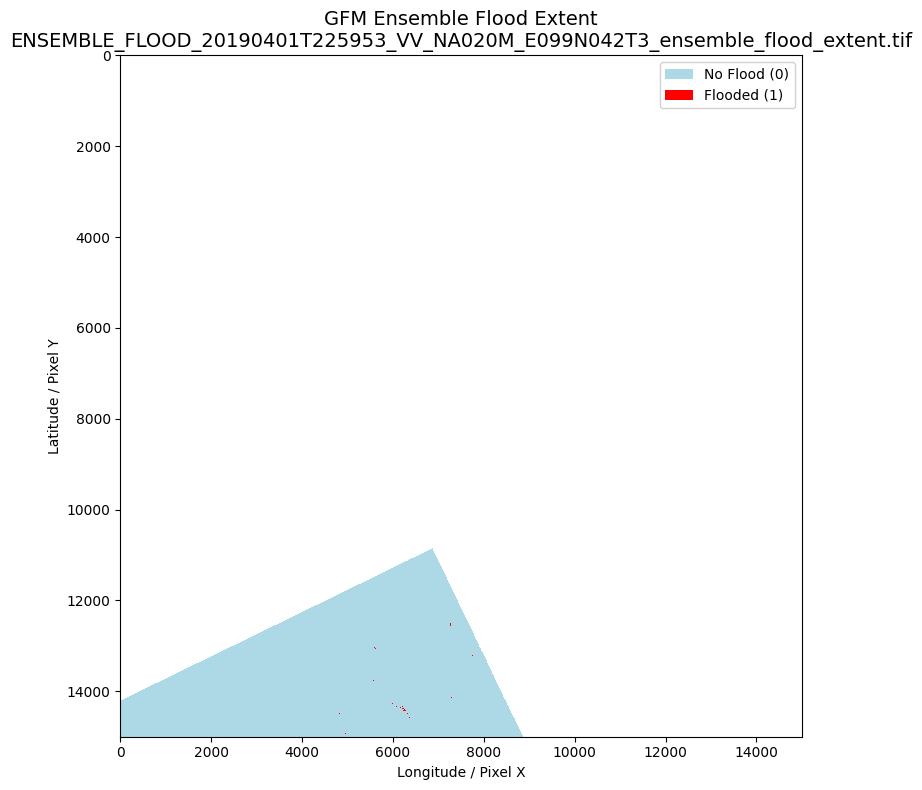

In [ ]:
visualize_gfm_benchmark(f"{CONFIG['PATHS']['raw']}/GFM_Benchmark_Gatineau/ENSEMBLE_FLOOD_20190401T225953_VV_NA020M_E099N042T3_ensemble_flood_extent.tif")

# GFM - Align

In [43]:
from rasterio.warp import reproject, Resampling

def align_target_to_master(master_path, target_path, output_path):
    print(f"Aligning {os.path.basename(target_path)} to {os.path.basename(master_path)}...")
    
    # Read the Master profile 
    with rasterio.open(master_path) as master:
        master_profile = master.profile
        master_transform = master.transform
        master_crs = master.crs
        
    # Read the Target and Reproject
    with rasterio.open(target_path) as target:
        profile = master_profile.copy()
        profile.update({
            'count': target.count,
            'dtype': target.dtypes[0],
            'nodata': 255 # GFM standard nodata value
        })
        
        with rasterio.open(output_path, 'w', **profile) as dst:
            for i in range(1, target.count + 1):
                reproject(
                    source=rasterio.band(target, i),
                    destination=rasterio.band(dst, i),
                    src_transform=target.transform,
                    src_crs=target.crs,
                    dst_transform=master_transform,
                    dst_crs=master_crs,
                    # USE NEAREST for categorical data (0s and 1s) to avoid interpolating decimals!
                    resampling=Resampling.nearest 
                )
    print(f"Saved aligned raster to: {output_path}")

## Run

In [ ]:
raw_dir = CONFIG["PATHS"]["local_raw"]
env_folder = f"Env_{clean_region_name}"
env_filename = f"{clean_region_name}_env_stack.tif"
master_env_path = os.path.join(raw_dir, env_folder, env_filename)

print(f"Master Environment Path: {master_env_path}")

Master Environment Path: ..\..\datasets\raw\Env_Gatineau\Gatineau_env_stack.tif


In [ ]:
if 'gfm_paths' in locals() and len(gfm_paths) > 0:
    gfm_raw_path = gfm_paths[0]
    print(f"Target GFM Path: {gfm_raw_path}")
    
    # 3. Create the Output Path for the Aligned File
    gfm_aligned_dir = Path(raw_dir) / f"GFM_Aligned_{clean_region_name}"
    gfm_aligned_dir.mkdir(parents=True, exist_ok=True)
    
    # Extract the original filename and add _Aligned
    original_gfm_name = os.path.basename(gfm_raw_path)
    aligned_gfm_filename = original_gfm_name.replace(".tif", "_Aligned.tif")
    aligned_gfm_path = os.path.join(gfm_aligned_dir, aligned_gfm_filename)
    
    print(f"Output Aligned Path: {aligned_gfm_path}")
    
    align_target_to_master(master_env_path, gfm_raw_path, aligned_gfm_path)
else:
    print("Error: 'gfm_paths' variable is not defined or is empty. Please run the STAC download cell first.")

Target GFM Path: ..\..\datasets\raw\GFM_Benchmark\ENSEMBLE_FLOOD_20190531T230021_VV_NA020M_E099N042T3_ensemble_flood_extent.tif
Output Aligned Path: ..\..\datasets\raw\GFM_Aligned\ENSEMBLE_FLOOD_20190531T230021_VV_NA020M_E099N042T3_ensemble_flood_extent_Aligned.tif
Aligning ENSEMBLE_FLOOD_20190531T230021_VV_NA020M_E099N042T3_ensemble_flood_extent.tif to Gatineau_env_stack.tif...
Saved aligned raster to: ..\..\datasets\raw\GFM_Aligned\ENSEMBLE_FLOOD_20190531T230021_VV_NA020M_E099N042T3_ensemble_flood_extent_Aligned.tif


### Visualize

Visualizing GFM Benchmark: ..\..\datasets\raw/GFM_Aligned/ENSEMBLE_FLOOD_20190531T230021_VV_NA020M_E099N042T3_ensemble_flood_extent_Aligned.tif


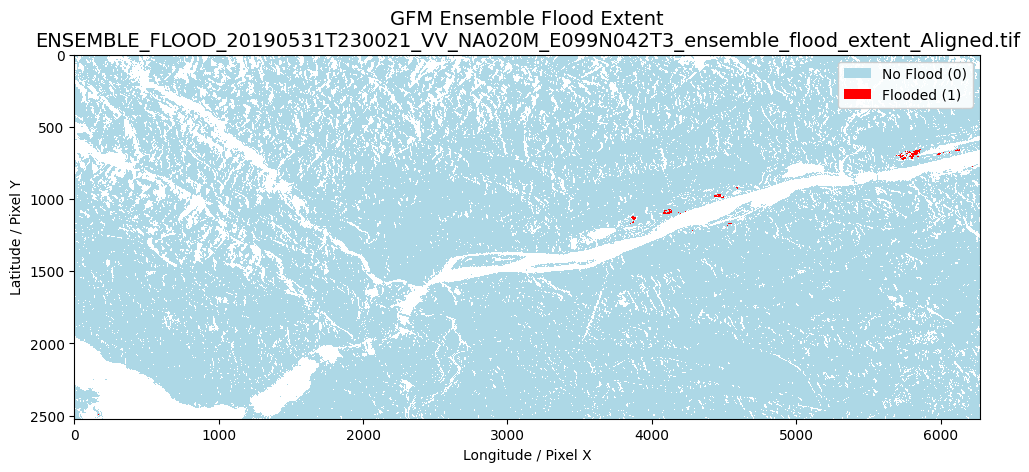

In [ ]:
visualize_gfm_benchmark(f"{CONFIG['PATHS']['raw']}/GFM_Aligned_Gatineau/ENSEMBLE_FLOOD_20190531T230021_VV_NA020M_E099N042T3_ensemble_flood_extent_Aligned.tif")

# Optional - GloFAS (Global Flood Awareness System)

- EU / Copernicus offering
- a flood awareness system 
- model forecast based on weather forecast from ECMWF and hydrology models
- coarse ~10km
- but it can be upto 30 days in advance
- European specific version - EFAS

In [38]:
import cdsapi
import xarray as xr
from rasterio.transform import from_origin

In [39]:
def fetch_glofas_historical(roi_geom, year, month, output_dir, clean_region_name):

    # Define the bounding box [North, West, South, East]
    # roi_geojson = roi_geom.getInfo()
    # roi_bbox = shape(roi_geojson).bounds 
    # area = [roi_bbox[3], roi_bbox[0], roi_bbox[1], roi_bbox[2]]

    coords = roi_geom.bounds().getInfo()['coordinates'][0]
    lons = [c[0] for c in coords]
    lats = [c[1] for c in coords]
    area = [max(lats), min(lons), min(lats), max(lons)]
    
    out_dir = Path(output_dir) / f"GloFAS_{clean_region_name}"
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"{clean_region_name}_GloFAS_{year}_{month}.nc"

    print("Connecting to Climate Data Store for GloFAS data...")
    
    try:
        c = cdsapi.Client()
        c.retrieve(
            'cems-glofas-historical',
            {
                'system_version': 'version_4_0',
                'hydrological_model': 'lisflood',
                'product_type': 'consolidated',
                'variable': 'river_discharge_in_the_last_24_hours',
                'hyear': [str(year)],
                'hmonth': [str(month).zfill(2)],
                'hday': [f"{i:02d}" for i in range(1, 32)], 
                'format': 'netcdf',
                'area': area,
            },
            str(out_path))
            
        print(f"[OK] GloFAS downloaded successfully to {out_path}")
        
        # Transform monthly NetCDF into Daily GeoTIFFs
        print("Slicing monthly NetCDF into daily GeoTIFFs...")
        ds = xr.open_dataset(out_path)
        var_name = 'dis24' if 'dis24' in ds.variables else list(ds.data_vars)[0]
        time_dim = [dim for dim in ds.dims if 'time' in dim.lower()][0]

        lon, lat = ds.longitude.values, ds.latitude.values
        lon_res, lat_res = abs(float(lon[1] - lon[0])), abs(float(lat[1] - lat[0]))

        nw_lat = float(lat[-1]) if lat[0] < lat[-1] else float(lat[0])
        nw_lon = float(min(lon[0], lon[-1]))
        transform = from_origin(nw_lon, nw_lat, lon_res, lat_res)

        # Loop through every day in the month
        for t in ds[time_dim].values:
            # Format datetime to string (e.g., '2019-04-01')
            date_str = pd.to_datetime(t).strftime('%Y-%m-%d')
            daily_slice = ds.sel({time_dim: t})[var_name].values
            
            if lat[0] < lat[-1]: 
                daily_slice = np.flipud(daily_slice)

            # Name the file explicitly to match your other daily data
            tif_path = out_dir / f"GLOFAS_{clean_region_name}_{date_str}.tif"
            
            with rasterio.open(
                tif_path, 'w', driver='GTiff',
                height=daily_slice.shape[0], width=daily_slice.shape[1],
                count=1, dtype=daily_slice.dtype, crs='EPSG:4326', transform=transform
            ) as dst:
                dst.write(daily_slice, 1)
        
        ds.close()
        
        # Delete the raw monthly NetCDF to save space now that we have the daily TIFs
        os.remove(out_path)
        print(f"[OK] Extracted all daily slices for {year}-{month} and cleaned up raw file.")
        
        return out_dir
        
    except Exception as e:
        print(f"CDS API Error or Slicing Error: {e}")
        return None

## Run

In [40]:
start_datetime = datetime.strptime(CONFIG["DATES"]["start"], "%Y-%m-%d")
year_str = start_datetime.strftime("%Y")
month_str = start_datetime.strftime("%m")

glofas_path = fetch_glofas_historical(
    roi_geom=roi, 
    year=year_str, 
    month=month_str, 
    output_dir=CONFIG["PATHS"]["local_raw"],
    clean_region_name=clean_region_name
)

Connecting to Climate Data Store for GloFAS data...


2026-03-31 15:10:29,675 INFO [2024-02-01T00:00:00] Please note that accessing this dataset via CDS for time-critical operation is not advised or supported
2026-03-31 15:10:29,676 INFO [2024-02-01T00:00:00] Please note we suggest checking the list of known issues on the GloFAS wiki
[here](https://confluence.ecmwf.int/display/CEMS/GloFAS+-+Known+Issues)
before downloading the dataset.
2026-03-31 15:10:29,678 INFO Request ID is 1f1a2a55-a5a5-4242-b610-46b455297eb4
2026-03-31 15:10:29,860 INFO status has been updated to accepted
2026-03-31 15:10:38,717 INFO status has been updated to running
2026-03-31 15:11:03,326 INFO status has been updated to successful


bff9a2003499ef98173f999fcbdb62f4.nc:   0%|          | 0.00/39.4k [00:00<?, ?B/s]

[OK] GloFAS downloaded successfully to ..\..\datasets\raw\GloFAS_Ottawa\Ottawa_GloFAS_2019_04.nc
Slicing monthly NetCDF into daily GeoTIFFs...
[OK] Extracted all daily slices for 2019-04 and cleaned up raw file.


### Visualize

In [ ]:
import xarray as xr

In [ ]:
def visualize_glofas(nc_path, location_name):
    print(f"Visualizing GloFAS Data - {nc_path}")
    
    if os.path.getsize(nc_path) < 10000:
        print("potential corrupt file")
        with open(nc_path, 'r') as f:
            print(f.read()[:500])
        return
    
    try:
        ds = xr.open_dataset(nc_path, engine='h5netcdf')
    except Exception:
        ds = xr.open_dataset(nc_path, engine='netcdf4')
        
    time_dim = 'valid_time' if 'valid_time' in ds.dims else 'time'
    lat_dim = 'latitude' if 'latitude' in ds.dims else 'lat'
    lon_dim = 'longitude' if 'longitude' in ds.dims else 'lon'
    
    # GloFAS discharge variable is typically named 'dis24'
    var_name = [v for v in ds.data_vars if 'dis' in v.lower()][0]
    discharge_data = ds[var_name]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"GloFAS River Discharge Analysis - {location_name}", fontsize=16)
    
    # Spatial Map (Maximum Discharge over the month) 
    max_discharge_spatial = discharge_data.max(dim=time_dim)
    
    max_discharge_spatial.plot(ax=axes[0], cmap='Blues', cbar_kwargs={'label': 'Max Discharge (m³/s)'})
    axes[0].set_title("Spatial Distribution of Max River Discharge")
    axes[0].set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")
    
    # Hydrograph (time Series of the peak flood) 
    peak_discharge_over_time = discharge_data.max(dim=[lat_dim, lon_dim])
    
    axes[1].plot(peak_discharge_over_time[time_dim], peak_discharge_over_time, marker='o', color='#1f77b4', linewidth=2)
    axes[1].set_title("Hydrograph: Regional Peak Discharge Over Time")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel("River Discharge (m³/s)")
    axes[1].grid(True, linestyle='--', alpha=0.7)
    
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    ds.close()

Visualizing GloFAS Data: ..\..\datasets\raw/GloFAS/Gatineau_GloFAS_2019_04.nc


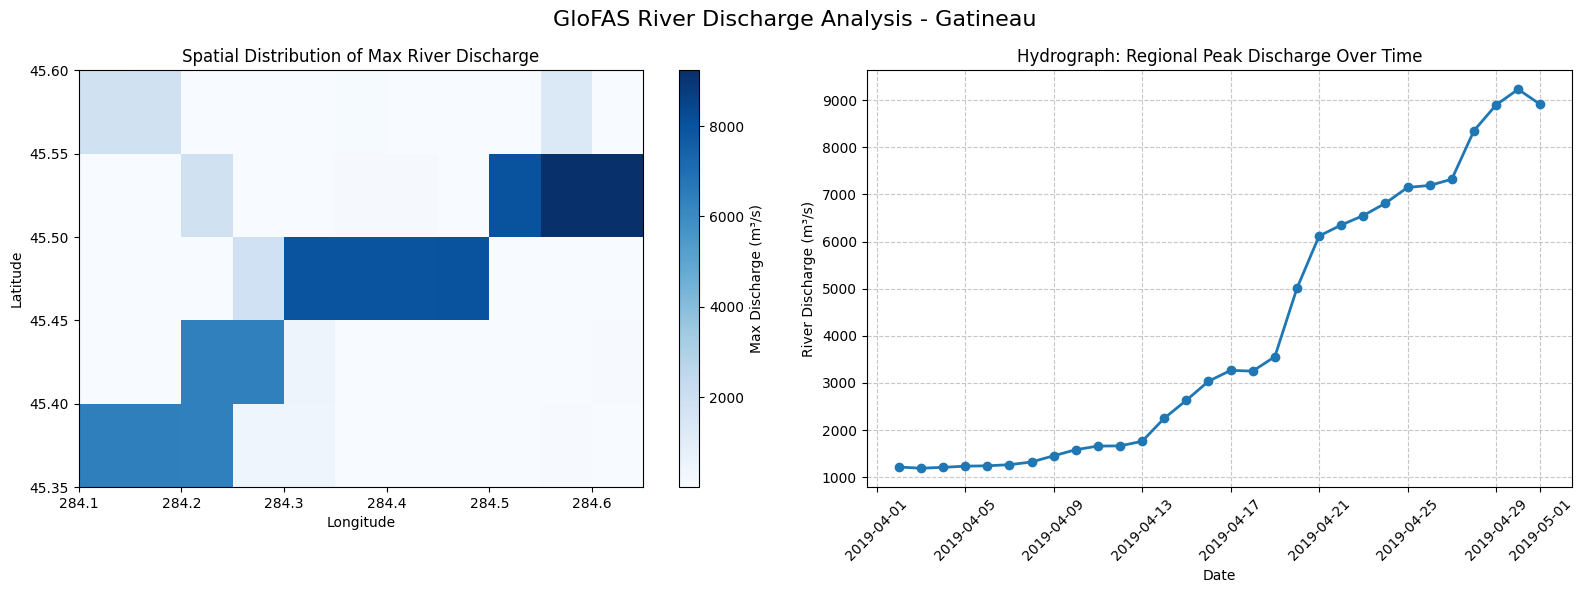

In [ ]:
glofas_file = f"{CONFIG['PATHS']['raw']}/GloFAS/{clean_region_name}_GloFAS_2019_04.nc"
visualize_glofas(glofas_file, clean_region_name)

# Optional - MODIS (Moderate Resolution Imaging Spectroradiometer)

- [NASA's](https://modis.gsfc.nasa.gov/about/) Terra and Aqua satellites
- Coarse 1px = 250-500m
- Optical (clouds are a problem)  
Hence not a great choice for flood labels for Sentinel-1's 10m radar resolution  
might be useful for long term global trends



In [36]:
def get_modis_ndwi_gee(roi, start_date, end_date):
    print("Fetching MODIS")
    
    # MOD09GA - Terra Surface Reflectance Daily L2G Global 500m
    modis_collection = (ee.ImageCollection("MODIS/061/MOD09GA")
                        .filterBounds(roi)
                        .filterDate(start_date, end_date))
    
    # Function to calculate NDWI and add it as a band
    # MODIS Band 4 = Green, Band 2 = NIR
    def add_ndwi(img):
        ndwi = img.normalizedDifference(['sur_refl_b04', 'sur_refl_b02']).rename('NDWI')
        # Mask clouds using the state_1km QA band
        qa = img.select('state_1km')
        cloud_mask = qa.bitwiseAnd(1 << 0).eq(0) # 0 = clear
        return img.addBands(ndwi).updateMask(cloud_mask)

    ndwi_collection = modis_collection.map(add_ndwi)
    
    # median composite for the time period
    ndwi_median = ndwi_collection.select('NDWI').median().clip(roi)
    return ndwi_median


In [ ]:
def export_modis_ndwi(roi, region_name, start_date, end_date, clean_region_name):
    ndwi_median = get_modis_ndwi_gee(roi, start_date, end_date)
    
    task = ee.batch.Export.image.toDrive(
        image=ndwi_median,
        description=f"{clean_region_name}_MODIS_NDWI",
        folder=f"Flood_Project_Data", 
        fileNamePrefix=f"MODIS_{clean_region_name}_modis_ndwi",
        region=roi,
        scale=500, # native MODIS resolution
        crs='EPSG:4326',
        maxPixels=1e9
    )
    task.start()
    print(f"MODIS NDWI export started for {clean_region_name}")

## Run

In [ ]:
export_modis_ndwi(roi, sub_region, start_date, end_date, clean_region_name)

Fetching MODIS
MODIS NDWI export started for Gatineau


In [ ]:
check_exports_gee(sub_region, start_date, end_date)  

Checking export status for Gatineau
Gatineau_MODIS_NDWI: COMPLETED
Gatineau_Env_Stack: COMPLETED


### Visualize

In [34]:
from matplotlib.colors import LinearSegmentedColormap

def visualize_modis_local(tif_path):
    print(f"Visualizing Local MODIS NDWI {tif_path}")
        
    with rasterio.open(tif_path) as src:
        # Read the first band (NDWI)
        ndwi = src.read(1)
        
        # Mask out NoData values less than -1.0 as NDWI theoretically stops at -1.0
        ndwi_masked = np.ma.masked_less(ndwi, -1.0)
        ndwi_masked = np.ma.masked_invalid(ndwi_masked)
        
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # (Brown -> Beige -> Blue)
    colors = ['#a52a2a', '#f5f5dc', '#0000ff']
    custom_cmap = LinearSegmentedColormap.from_list('ndwi_cmap', colors, N=256)
    
    # setting limits to highlight the transition around 0
    # values > 0 are - water or highly saturated soil
    im = ax.imshow(ndwi_masked, cmap=custom_cmap, vmin=-0.3, vmax=0.3)
    
    ax.set_title(f"MODIS NDWI (Surface Wetness)\n{os.path.basename(tif_path)}", fontsize=14)
    ax.set_xlabel("Pixel X")
    ax.set_ylabel("Pixel Y")
    
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("NDWI")
    
    plt.tight_layout()
    plt.show()

Visualizing Local MODIS NDWI ..\..\datasets\raw/MODIS_Gatineau/Gatineau_MODIS_NDWI.tif


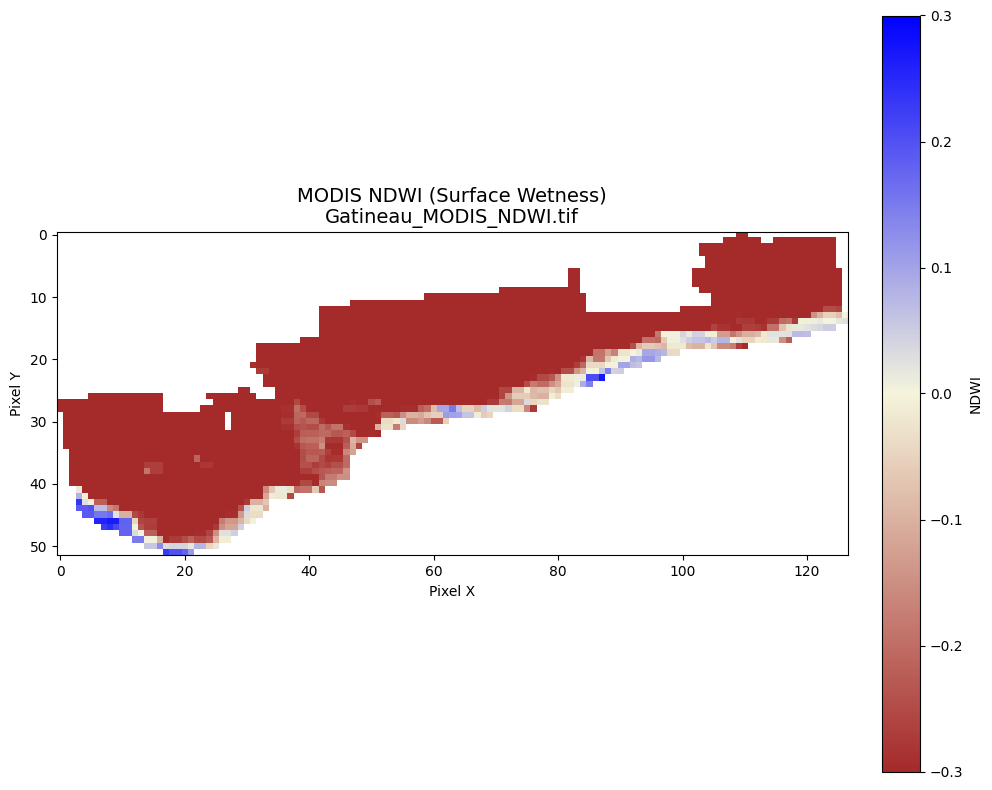

In [ ]:
modis_local_path = f"{CONFIG['PATHS']['raw']}/MODIS_{clean_region_name}/{clean_region_name}_MODIS_NDWI.tif"

visualize_modis_local(modis_local_path)

# Optional - Hydro -  MERIT 
- hydro model outputs 
- 90m spatial res
- based on DEM
- earlier SHEDS, MERITS new
- alternative - NHDPlus (US)

In [38]:
def get_hydro_gee(roi):

    # River Network & Distance to River (MERIT Hydro)- Upstream Drainage Area to define river
    merit = ee.Image("MERIT/Hydro/v1_0_1")
    
    # Threshold upstream area to define the river network (> 100 km^2)
    river_network = merit.select('upa').gt(100) 
    
    # distance to the nearest river pixel (fastDistanceTransform returns distance in pixels)
    # Multiply by pixel resolution (~90m for MERIT) to get approximate meters
    distance_to_river = river_network.fastDistanceTransform() \
                                     .multiply(90) \
                                     .rename('distance_to_river') \
                                     .clip(roi)
                                     
    
    return distance_to_river

In [39]:
def export_hydro_stack(roi, region_name, clean_region_name):
    hydro_stack = get_hydro_gee(roi) 
    
    task = ee.batch.Export.image.toDrive(
        image=hydro_stack.float(),
        description=f"{clean_region_name}_Hydro_MERIT",
        folder=f"Flood_Project_Data",
        fileNamePrefix=f"HYDRO_MERIT_{clean_region_name}_hydro_merit",
        region=roi,
        scale=CONFIG['PARAMS']['s1_resolution'], # Resamples to 10m to match S1
        crs='EPSG:4326',
        maxPixels=1e13 #limit large rois
    )
    task.start()
    print(f"MERIT Hydro export started for {clean_region_name}")

## Run

In [ ]:
export_hydro_stack(roi, sub_region, clean_region_name)

MERIT Hydro export started for Gatineau


In [82]:
check_exports_gee(sub_region, start_date, end_date)  

Checking export status for Gatineau
Gatineau_Hydro_MERIT: RUNNING
Gatineau_Hydro_MERIT: FAILED
Gatineau_Boundary: COMPLETED
Gatineau_Boundary: COMPLETED
Gatineau_Boundary: COMPLETED
Gatineau_MODIS_NDWI: COMPLETED
Gatineau_Env_Stack: COMPLETED
1 tasks are still running on Google Cloud https://code.earthengine.google.com/tasks


### Visualize

In [83]:
from rasterio.plot import show

def visualize_hydro_local(file_path, is_radar=False):
    with rasterio.open(file_path) as src:
        print(f"--- File Metadata ---")
        print(f"File: {file_path}")
        print(f"Shape (Bands, Rows, Cols): {src.count}, {src.height}, {src.width}")
        print(f"Coordinate Reference System: {src.crs}")
        print(f"Data Type: {src.dtypes[0]}")
        
        fig, ax = plt.subplots(figsize=(10, 8))
        
        if is_radar and src.count >= 2:
            # Sentinel-1 VV and VH bands.
            # Radar backscatter values have massive outliers - clip to the 2nd - 98th percentiles 
            vv = src.read(1)
            
            vmin, vmax = np.percentile(vv[~np.isnan(vv)], 2), np.percentile(vv[~np.isnan(vv)], 98)
            
            show(vv, ax=ax, cmap='gray', vmin=vmin, vmax=vmax, transform=src.transform)
            ax.set_title("Sentinel-1 VV Polarization (Local)")
            
        else:
            band1 = src.read(1)
            
            show(band1, ax=ax, cmap='viridis', transform=src.transform)
            ax.set_title(f"Local Raster Visualization (Band 1)")
            
        plt.show()

--- File Metadata ---
File: ..\..\datasets\raw/HYDRO_MERIT_Gatineau/Gatineau_hydro_merit.tif
Shape (Bands, Rows, Cols): 1, 2522, 6274
Coordinate Reference System: EPSG:4326
Data Type: float32


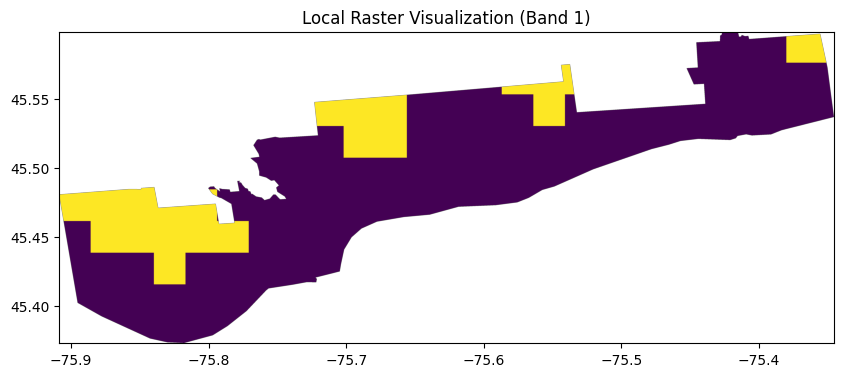

In [ ]:
visualize_hydro_local(f"{CONFIG['PATHS']['raw']}/HYDRO_MERIT_{clean_region_name}/{clean_region_name}_hydro_merit.tif", is_radar=False)

# Weather 

## Precipitation - GPM IMERG (Global Precipitation Measurement)
- global - every 30 min - radar + microwave
- 10km spatial res (way coarser than S1's 10m)
- alternative - CHIRPS (long term res), NEXRAD, MRMS (only North America)


## Soil Moisture - SMAP (Soil Moisture Active Passive)
- global - inspects top 5 cm of soil with microwaves
- every 2-3days, spatial res 9-40km
- alternative - SMOS (ESA), GLDAS (model estimate) 


## ERA5 (ECMWF Re Analysis) - Historical analysis of HRES
- Global, historic hourly (processed starting 1940), 30km spatial res

In [40]:
def get_weather_gee(roi, target_date):
    # GPM IMERG Precipitation 
    # half hourly data but aggregated to daily/multiday sums
    gpm = ee.ImageCollection("NASA/GPM_L3/IMERG_V07") \
            .select('precipitation')
            
    def get_cumulative_precip(days_back):
        start_date = target_date.advance(-days_back, 'day')
        return gpm.filterDate(start_date, target_date) \
                  .sum() \
                  .rename(f'precip_{days_back}d_sum') \
                  .clip(roi)

    # cumulative - ( 1d, 3d, 7d) 
    precip_1d = get_cumulative_precip(1)
    precip_3d = get_cumulative_precip(3)
    precip_7d = get_cumulative_precip(7)
    
    # SMAP Soil Moisture - run offs
    # NASA_USDA/HSL/SMAP10KM_soil_moisture - ssm
    # NASA/SMAP/SPL4SMGP/007 - sm
    smap = ee.ImageCollection("NASA/SMAP/SPL4SMGP/007") \
             .filterDate(target_date.advance(-3, 'day'), target_date) \
             .select('sm_surface') \
             .mean() \
             .rename('soil_moisture') \
             .clip(roi)
             
    # ERA5 - temperature and total evaporation context
    era5 = ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY") \
             .filterDate(target_date.advance(-1, 'day'), target_date) \
             .select(['temperature_2m', 'total_evaporation']) \
             .mean() \
             .clip(roi)
                                     
    weather_stac = ee.Image([
        precip_1d, 
        precip_3d, 
        precip_7d, 
        smap, 
        era5
    ])
    
    return weather_stac

In [41]:
def export_weather_stack(roi, region_name, start_date, end_date, clean_region_name):
    date_list = pd.date_range(start=start_date, end=end_date, freq='D')
    
    print(f"Queueing {len(date_list)} weather exports for {clean_region_name}...")
    print(f"Range: {start_date} to {end_date}")
    
    for pd_date in date_list:
        date_str = pd_date.strftime('%Y-%m-%d')
        ee_date = ee.Date(date_str)
        
        weather_stack = get_weather_gee(roi, ee_date)
    
        task = ee.batch.Export.image.toDrive(
            image=weather_stack.float(),
            description=f"{clean_region_name}_Weather_1km_{date_str}",
            folder=f"Flood_Project_Data",
            fileNamePrefix=f"WEATHER_{clean_region_name}_weather_1km_{date_str}",
            region=roi,
            scale=1000, # 1km resolution 
            crs='EPSG:4326',
            maxPixels=1e13 
        )
        task.start()
        print(f"Task started: Weather stack for {date_str}")


## Run

In [ ]:
export_weather_stack(roi, sub_region, start_date, end_date, clean_region_name)

Queueing 61 weather exports for Gatineau...
Range: 2019-04-01 to 2019-05-31
Task started: Weather stack for 2019-04-01
Task started: Weather stack for 2019-04-02
Task started: Weather stack for 2019-04-03
Task started: Weather stack for 2019-04-04
Task started: Weather stack for 2019-04-05
Task started: Weather stack for 2019-04-06
Task started: Weather stack for 2019-04-07
Task started: Weather stack for 2019-04-08
Task started: Weather stack for 2019-04-09
Task started: Weather stack for 2019-04-10
Task started: Weather stack for 2019-04-11
Task started: Weather stack for 2019-04-12
Task started: Weather stack for 2019-04-13
Task started: Weather stack for 2019-04-14
Task started: Weather stack for 2019-04-15
Task started: Weather stack for 2019-04-16
Task started: Weather stack for 2019-04-17
Task started: Weather stack for 2019-04-18
Task started: Weather stack for 2019-04-19
Task started: Weather stack for 2019-04-20
Task started: Weather stack for 2019-04-21
Task started: Weather

In [109]:
check_exports_gee(sub_region, start_date, end_date)

Checking export status for Gatineau
Gatineau_Weather_1km_2019-05-31: COMPLETED
Gatineau_Weather_1km_2019-05-30: COMPLETED
Gatineau_Weather_1km_2019-05-29: COMPLETED
Gatineau_Weather_1km_2019-05-28: COMPLETED
Gatineau_Weather_1km_2019-05-27: COMPLETED
Gatineau_Weather_1km_2019-05-26: COMPLETED
Gatineau_Weather_1km_2019-05-25: COMPLETED
Gatineau_Weather_1km_2019-05-24: COMPLETED
Gatineau_Weather_1km_2019-05-23: COMPLETED
Gatineau_Weather_1km_2019-05-22: COMPLETED


### Visualize

In [48]:
from rasterio.plot import show

def visualize_local_weather_tiff(file_path, band_index=2, cmap='Blues', title="3-Day Precipitation"):
    """
    1: precip_1d_sum
    2: precip_3d_sum
    3: precip_7d_sum
    4: soil_moisture
    5: temperature_2m
    6: total_evaporation
    """
    with rasterio.open(file_path) as src:
        print(f"--- Weather File Metadata ---")
        print(f"File: {file_path}")
        print(f"Total Bands: {src.count}")
        print(f"Spatial Resolution: {src.res} (Should be ~0.0089 degrees / 1km)")
        
        band_data = src.read(band_index)
        
        fig, ax = plt.subplots(figsize=(10, 8))
        img = show(band_data, ax=ax, cmap=cmap, transform=src.transform)
        ax.set_title(f"Local Raster: {title} (Band {band_index})")
        
        fig.colorbar(img.get_images()[0], ax=ax, fraction=0.046, pad=0.04, label="Value")
        plt.show()


--- Weather File Metadata ---
File: ..\..\datasets\raw\Gatineau1\WEATHER_Gatineau\Gatineau_weather_1km_2019-04-01.tif
Total Bands: 6
Spatial Resolution: (0.008983152841195215, 0.008983152841195215) (Should be ~0.0089 degrees / 1km)


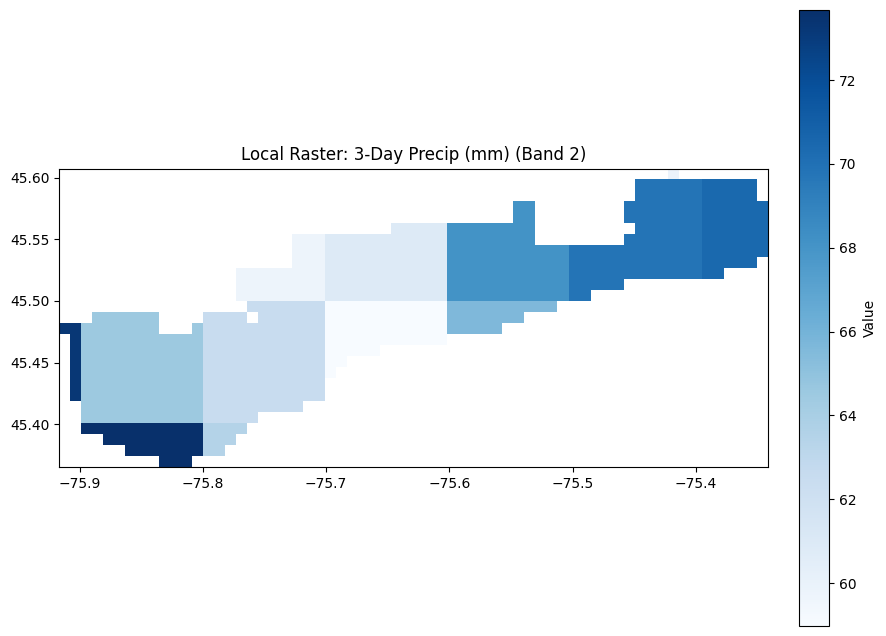

--- Weather File Metadata ---
File: ..\..\datasets\raw\Gatineau1\WEATHER_Gatineau\Gatineau_weather_1km_2019-04-01.tif
Total Bands: 6
Spatial Resolution: (0.008983152841195215, 0.008983152841195215) (Should be ~0.0089 degrees / 1km)


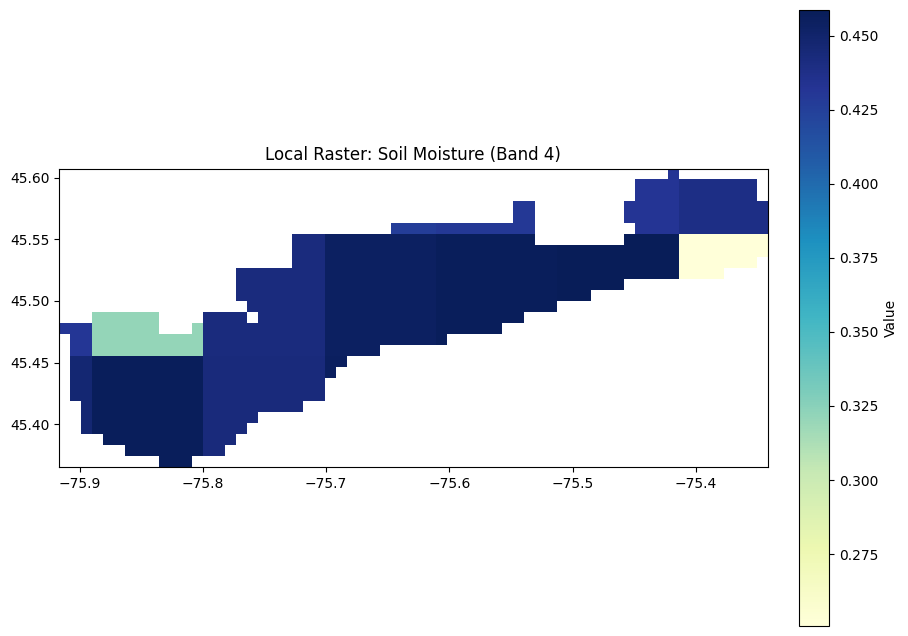

--- Weather File Metadata ---
File: ..\..\datasets\raw\Gatineau1\WEATHER_Gatineau\Gatineau_weather_1km_2019-04-01.tif
Total Bands: 6
Spatial Resolution: (0.008983152841195215, 0.008983152841195215) (Should be ~0.0089 degrees / 1km)


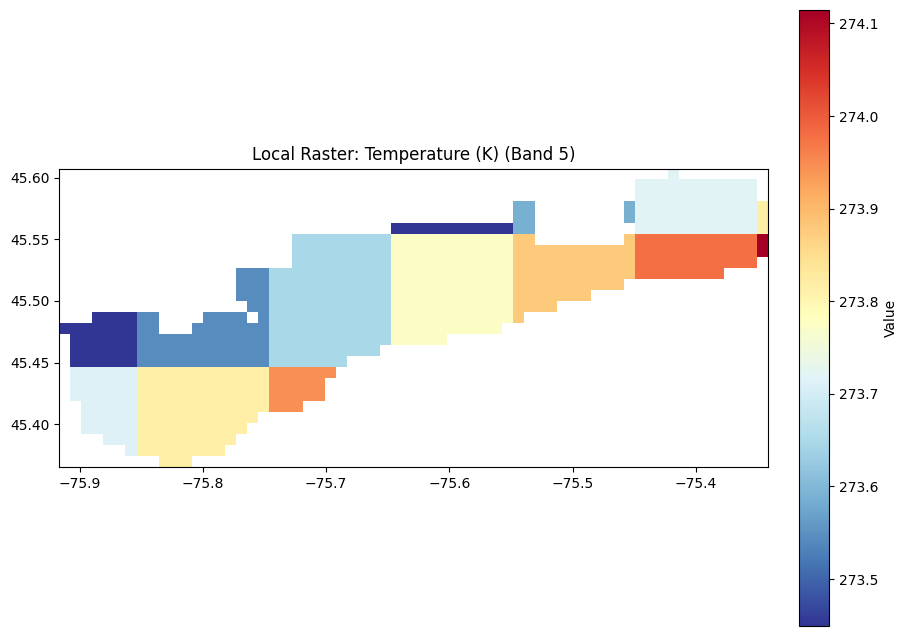

In [54]:
weather_file = f"{CONFIG['PATHS']['local_raw']}\Gatineau1\WEATHER_Gatineau\Gatineau_weather_1km_2019-04-01.tif"

# 3-Day Precipitation (Band 2)
visualize_local_weather_tiff(weather_file, band_index=2, cmap='Blues', title="3-Day Precip (mm)")

# Soil Moisture (Band 4)
visualize_local_weather_tiff(weather_file, band_index=4, cmap='YlGnBu', title="Soil Moisture")

# Temperature (Band 5)
visualize_local_weather_tiff(weather_file, band_index=5, cmap='RdYlBu_r', title="Temperature (K)")

# Pipeline - Run all

In [ ]:
def run_extraction_pipeline(loc_index, config=CONFIG):
    loc = config["LOCATIONS"][loc_index]
    clean_region_name = loc["name"]
    country = loc["country"]
    sub_region = loc["sub_region"]
    level = loc["level"]
    
    start_date = config["DATES"]["start"]
    end_date = config["DATES"]["end"]
    raw_path = config["PATHS"]["local_raw"]

    print("="*60)
    print(f"STARTING DATA PIPELINE FOR: {clean_region_name.upper()} ({sub_region}, {country})")
    print("="*60)

    # Extract Region of Interest (ROI)
    print(f"\n[1/5] Fetching GEE Administrative Boundary...")
    roi = export_boundary_gee(country, sub_region, level, clean_region_name)
    # get_administrative_boundary_gee(country, sub_region, level)

    # Queue Google Earth Engine Tasks
    print(f"\n[2/5] Queuing Earth Engine Exports to Google Drive...")
    export_daily_s1(roi, sub_region, start_date, end_date, clean_region_name)
    export_env_stack(roi, region_name=sub_region, clean_region_name=clean_region_name)
    export_modis_ndwi(roi, sub_region, start_date, end_date, clean_region_name)
    export_hydro_stack(roi, region_name=sub_region, clean_region_name=clean_region_name)
    export_weather_stack(roi, sub_region, start_date, end_date,clean_region_name)
    print("Checking Task Status...")
    check_exports_gee(sub_region, start_date, end_date)

    # Download GFM Benchmark (Copernicus STAC)
    print(f"\n[3/5] Downloading Global Flood Monitoring (GFM) Benchmarks...")
    gfm_output_dir = raw_path / f"GFM_Benchmark_{clean_region_name}"
    gfm_paths = download_gfm_benchmark_stac(
        roi_geom=roi, 
        start_date=start_date, 
        end_date=end_date, 
        output_dir=gfm_output_dir
    )

    # Download GloFAS River Discharge (Copernicus CDS/EWDS)
    print(f"\n[4/5] Downloading GloFAS Historical River Discharge...")
    start_datetime = datetime.strptime(start_date, "%Y-%m-%d")
    year_str = start_datetime.strftime("%Y")
    month_str = start_datetime.strftime("%m")
    
    glofas_path = fetch_glofas_historical(
        roi_geom=roi, 
        year=year_str, 
        month=month_str, 
        output_dir=raw_path,
        clean_region_name=clean_region_name
    )

    print(f"\n[5/5]  Pipeline Queued Successfully for {clean_region_name}!")
    print(f"   -> GFM Paths: {len(gfm_paths) if gfm_paths else 0} files downloaded")
    print(f"   -> GloFAS Path: {glofas_path}")
    print("\n IMPORTANT: You must wait for your Earth Engine tasks to finish and download the GeoTIFFs to your local 'raw' folder")
    
    return {
        "roi": roi,
        "sub_region": sub_region,
        "gfm_paths": gfm_paths,
        "glofas_path": glofas_path,
        "clean_region_name": clean_region_name
    }

In [45]:
request_details = run_extraction_pipeline(loc_index=1, config=CONFIG)

STARTING DATA PIPELINE FOR: OTTAWA (Ottawa, Canada)

[1/5] Fetching GEE Administrative Boundary...
Queuing ROI boundary export for Ottawa
Fetching geometry for Ottawa, Canada (Level 2)
Export started - Ottawa_boundary.geojson

[2/5] Queuing Earth Engine Exports to Google Drive...
Queueing 61 weather exports for Ottawa...
Range: 2019-04-01 to 2019-05-31


c:\Users\aquaf\anaconda3\envs\floodPred\lib\site-packages\ee\deprecation.py:215: DeprecationWarning: 

Attention required for NASA/SMAP/SPL4SMGP/007! You are using a deprecated asset.
To make sure your code keeps working, please update it.
This dataset has been superseded by NASA/SMAP/SPL4SMGP/008

Learn more: https://developers.google.com/earth-engine/datasets/catalog/NASA_SMAP_SPL4SMGP_007

  warnings.warn(warning, category=DeprecationWarning)


Task started: Weather stack for 2019-04-01
Task started: Weather stack for 2019-04-02
Task started: Weather stack for 2019-04-03
Task started: Weather stack for 2019-04-04
Task started: Weather stack for 2019-04-05
Task started: Weather stack for 2019-04-06
Task started: Weather stack for 2019-04-07
Task started: Weather stack for 2019-04-08
Task started: Weather stack for 2019-04-09
Task started: Weather stack for 2019-04-10
Task started: Weather stack for 2019-04-11
Task started: Weather stack for 2019-04-12
Task started: Weather stack for 2019-04-13
Task started: Weather stack for 2019-04-14
Task started: Weather stack for 2019-04-15
Task started: Weather stack for 2019-04-16
Task started: Weather stack for 2019-04-17
Task started: Weather stack for 2019-04-18
Task started: Weather stack for 2019-04-19
Task started: Weather stack for 2019-04-20
Task started: Weather stack for 2019-04-21
Task started: Weather stack for 2019-04-22
Task started: Weather stack for 2019-04-23
Task starte

In [57]:
loc = CONFIG["LOCATIONS"][1]
clean_region_name = loc["name"]
country = loc["country"]
sub_region = loc["sub_region"]
level = loc["level"]

start_date = CONFIG["DATES"]["start"]
end_date = CONFIG["DATES"]["end"]
raw_path = CONFIG["PATHS"]["local_raw"]

local_path = (CONFIG["PATHS"]["local_raw"] / clean_region_name)
local_path.mkdir(parents=True, exist_ok=True)

drive_path = CONFIG["PATHS"]["google_drive"]

check_exports_gee(sub_region, start_date, end_date)  

Checking export status for Ottawa
Ottawa_Weather_1km_2019-05-31: COMPLETED
Ottawa_Weather_1km_2019-05-30: COMPLETED
Ottawa_Weather_1km_2019-05-29: COMPLETED
Ottawa_Weather_1km_2019-05-28: COMPLETED
Ottawa_Weather_1km_2019-05-27: COMPLETED
Ottawa_Weather_1km_2019-05-26: COMPLETED
Ottawa_Weather_1km_2019-05-25: COMPLETED
Ottawa_Weather_1km_2019-05-24: COMPLETED
Ottawa_Weather_1km_2019-05-23: COMPLETED
Ottawa_Weather_1km_2019-05-22: COMPLETED


In [58]:
sync_and_organize_data(drive_path, local_path, clean_region_name)

Syncing data for Ottawa from G:\My Drive\Flood_Project_Data
Copied: GAUL_Ottawa_boundary.geojson
Copied: S1_Ottawa_S1_2019-04-25.tif
Copied: S1_Ottawa_S1_2019-04-08.tif
Copied: S1_Ottawa_S1_2019-04-01.tif
Copied: S1_Ottawa_S1_2019-04-13.tif
Copied: S1_Ottawa_S1_2019-05-02.tif
Copied: S1_Ottawa_S1_2019-05-07.tif
Copied: S1_Ottawa_S1_2019-05-14.tif
Copied: S1_Ottawa_S1_2019-05-26.tif
Copied: S1_Ottawa_S1_2019-05-19.tif
Copied: ENV_Ottawa_env_stack.tif
Copied: WEATHER_Ottawa_weather_1km_2019-04-02.tif
Copied: WEATHER_Ottawa_weather_1km_2019-04-01.tif
Copied: WEATHER_Ottawa_weather_1km_2019-04-05.tif
Copied: WEATHER_Ottawa_weather_1km_2019-04-03.tif
Copied: WEATHER_Ottawa_weather_1km_2019-04-04.tif
Copied: WEATHER_Ottawa_weather_1km_2019-04-06.tif
Copied: WEATHER_Ottawa_weather_1km_2019-04-08.tif
Copied: WEATHER_Ottawa_weather_1km_2019-04-07.tif
Copied: WEATHER_Ottawa_weather_1km_2019-04-09.tif
Copied: WEATHER_Ottawa_weather_1km_2019-04-11.tif
Copied: WEATHER_Ottawa_weather_1km_2019-04-10.